# Exporation of mhd_ch4_formatted_v1.csv 

df_mhd_ch4_raw : raw data

df_mhd_ch4_v1: one-hot flags

df_mhd_ch4_v2: a copy of df_mhd_ch4_v1

df_mhd_ch4_v3:drop the feature contains almost all are nan values

df_mhd_ch4_drop: drop extreme values from psamp and pflow


In [1]:
import seaborn as sns
sns.set_theme(style='darkgrid')

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# read data files
df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")
df_mhd_ch4_raw.head(20)


/tmp/ipykernel_17498/4231044995.py:6: DtypeWarning: Columns (37,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mhd_ch4_raw = pd.read_csv("../data/processed/mhd_ch4_formatted_v1.csv")


,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,NaN,NaN,NaN,NaN
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,...,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,NaN,NaN


In [3]:
df_mhd_ch4_raw.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,...,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
817954,260518,81300,std,J-286,J-286,3,0.0,40.0,22.23,NaN,...,NaN,NaN,NaN,14.873,NaN,2015.923,NaN,NaN,A,NaN


In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_mhd_ch4_raw[['CH4_flag_ht', 'CH4_flag_a','CH4_flag', 'CH4_flag_p']]= df_mhd_ch4_raw[['CH4_flag_ht', 'CH4_flag_a',	'CH4_flag', 'CH4_flag_p']].fillna(' ')

In [6]:
df_mhd_ch4_raw.iloc[[11123]]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
11123,940802,114700,std,G-028,G-028,1,0.0,40.0,23.89,NaN,845.8,755.08,NaN,755.0,96.6,7.49,167864.0,1361425.0,1.08,84.2,131.8,42828.0,42892.0,0.99917,1.0001,0.99917,0.999,0.9999,1.0,0.99917,1.0001,0.99917,1671.33,1672.89,1671.33,2.264,NaN,1672.724,,,,


print(df_mhd_ch4_raw['ploop']-(df_mhd_ch4_raw['ploop'].isnull()))

total: 817955
all non-null: date, time, sample,standard, port, ht, CH4_Cstd
all null:  temp,  ploop 

In [7]:
df_mhd_ch4_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 42 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   date             817955 non-null  int64  
 1   time             817955 non-null  int64  
 2   type             817955 non-null  object 
 3   sample           817955 non-null  object 
 4   standard         817955 non-null  object 
 5   port             817955 non-null  int64  
 6   ht               817955 non-null  float64
 7   tmod             705671 non-null  float64
 8   tamb             705670 non-null  float64
 9   lab_temp         1 non-null       float64
 10  pflow            815553 non-null  float64
 11  psamp            815625 non-null  float64
 12  ploop            1 non-null       float64
 13  pamb             815551 non-null  float64
 14  CH4_rt           816365 non-null  float64
 15  CH4_w            816365 non-null  float64
 16  CH4_ht           816365 non-null  floa

 9   temp             1 non-null       float64
12  ploop            1 non-null       float64
 41  CH4_flag_p       0 non-null       float64

 ----------
 almost all Nan
 maybe no use for training ml model

In [8]:
string_list = ['type', 'sample', 'standard', 'CH4_flag_ht', 'CH4_flag_a', 'CH4_flag']
for i in string_list:
    print(f"{i} values including:,{df_mhd_ch4_raw[i].value_counts()}", "\n")

type values including:,type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal30           6
cal225          6
cal300          6
cal120          6
cal60           6
cal180          6
cal90           6
cal45           4
cal15           3
cal165          3
cal135          3
cal75           3
cal105          3
cal250          3
cal200          3
cal500          3
-               1
Name: count, dtype: int64 

sample values including:,sample
10m          335171
9m            34964
J-273         12205
J-254         11469
J-231         11315
              ...  
UAN990635         1
UAN990624         1
UAN990623         1
H-313             1
-                 1
Name: count, Length: 520, dtype: int64 

standard values including:,standard
J-273        24266
J-254        22463
J-231        22202
J-197        21469

/tmp/ipykernel_17498/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_17498/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_17498/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_17498/1842129789.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_17498/1842129789.py:9: FutureWarn

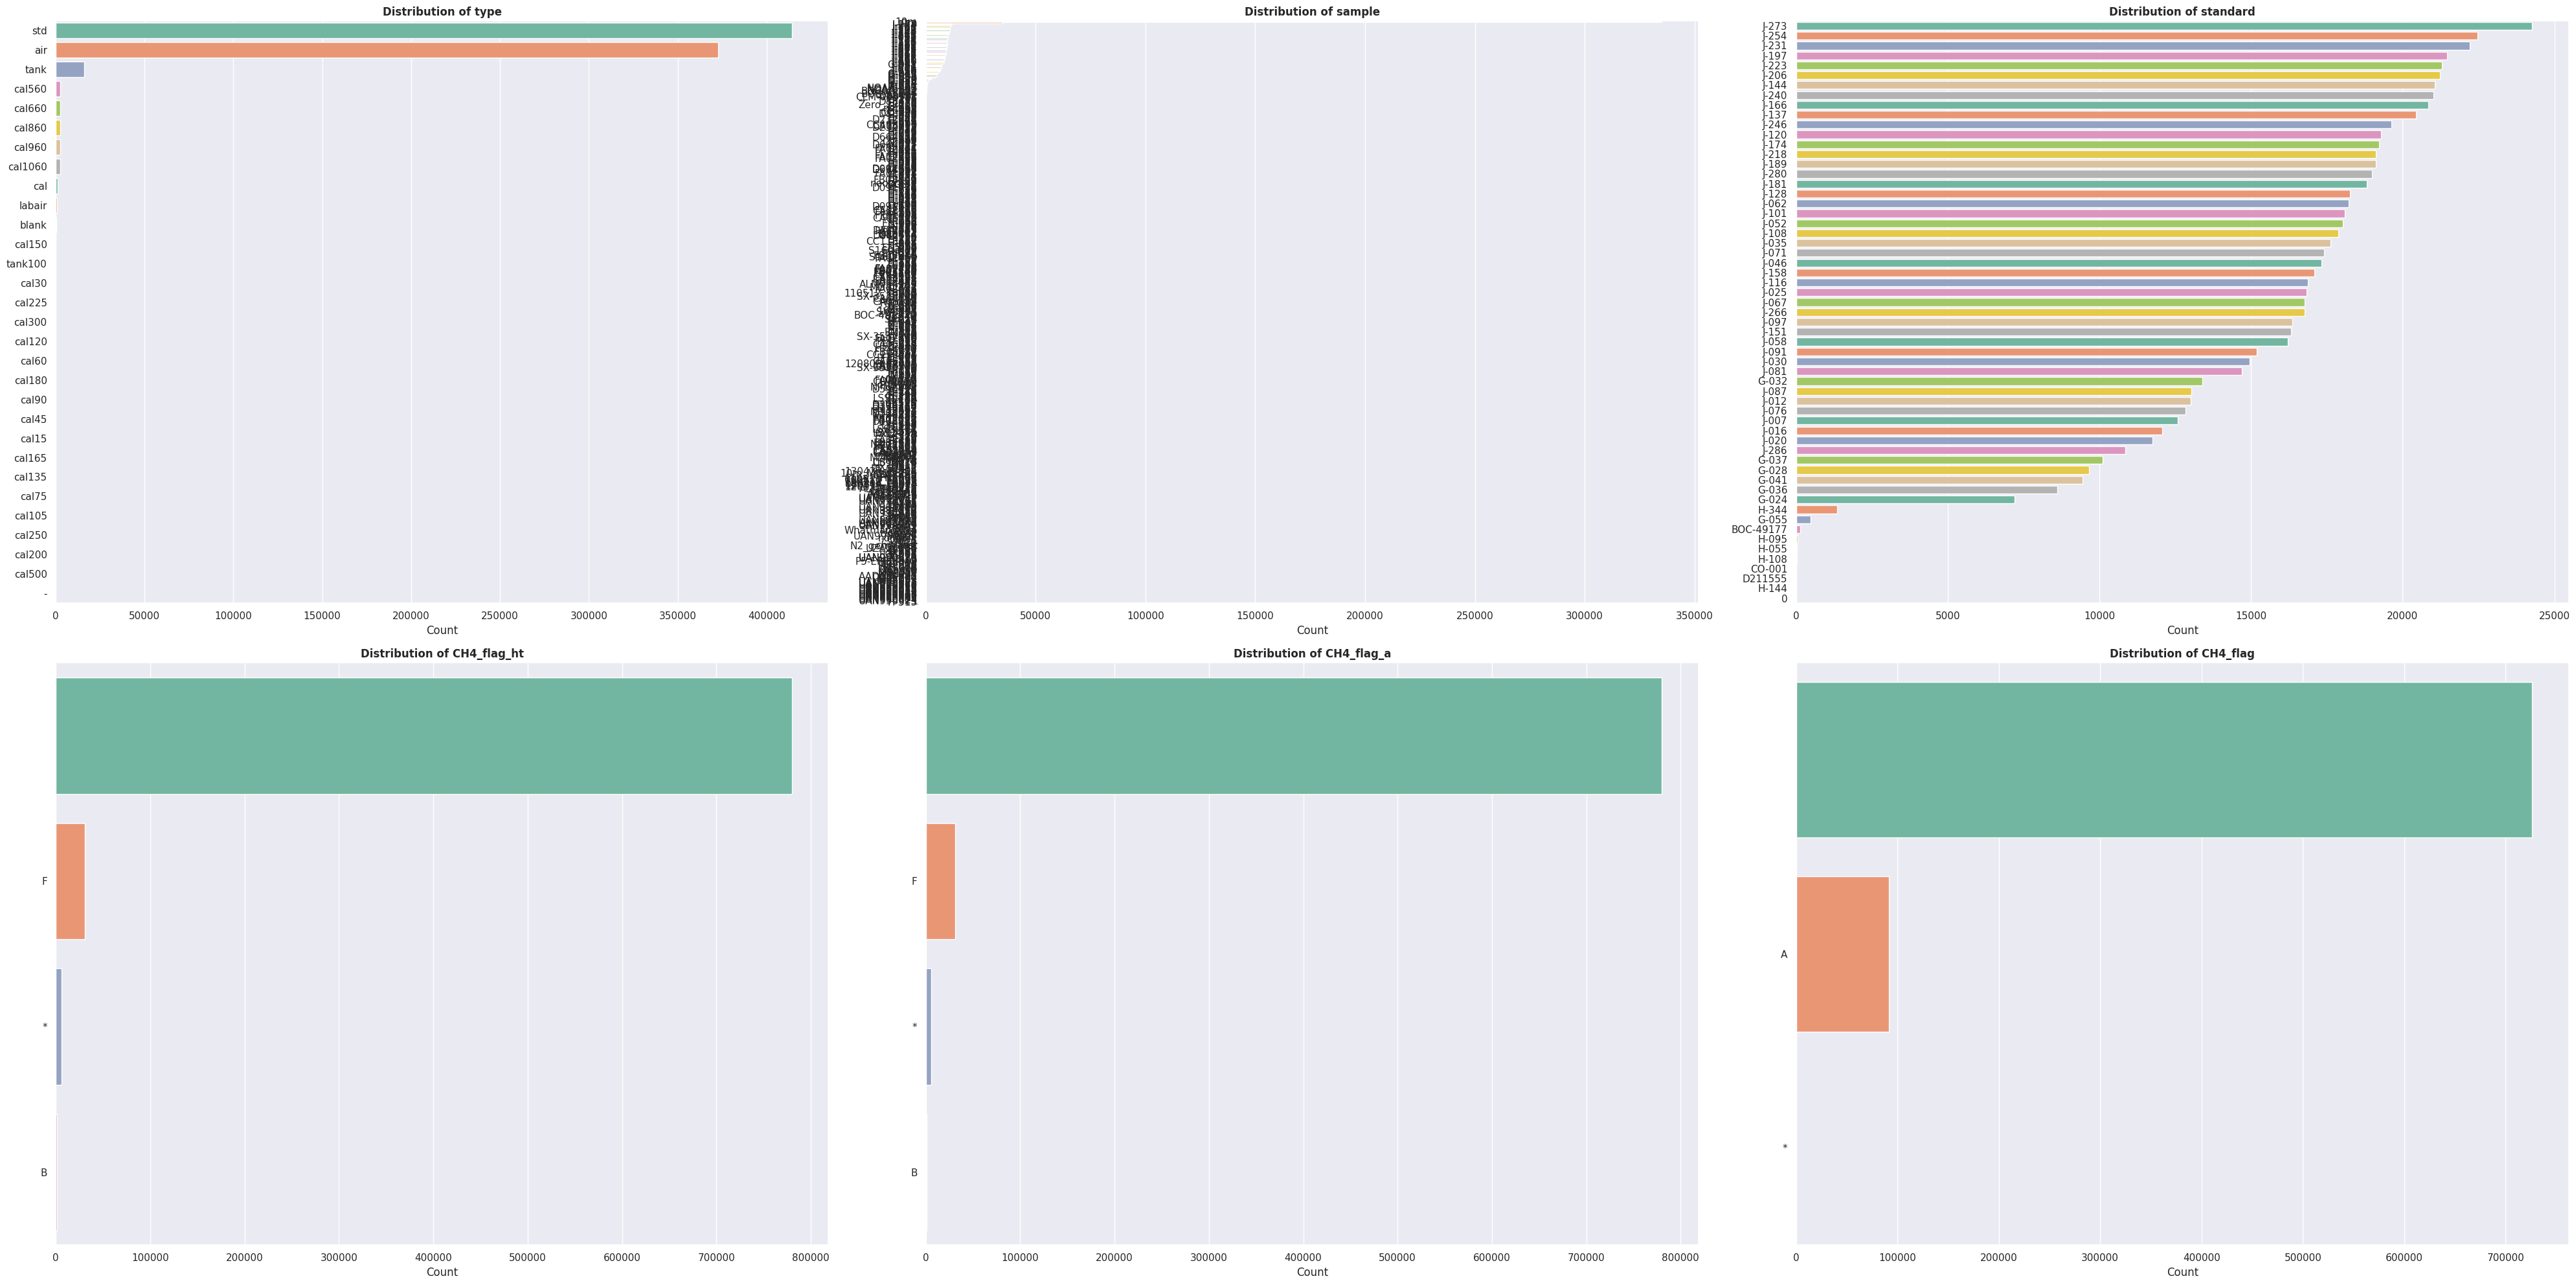

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2,3, figsize=(40, 20))

axes = axes.flatten()

for i, col in enumerate(string_list):
    if col in df_mhd_ch4_raw.columns:
        sns.countplot(
            data=df_mhd_ch4_raw,
            y=col,
            ax=axes[i],
            order = df_mhd_ch4_raw[col].value_counts().index,
            palette='Set2'
        )
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Count')
        axes[i].set_ylabel('')

    else:
        axes[i].set_title(f'{col} (Not Found)')

plt.tight_layout()
plt.show()

The distribution plot of sample is too narrow
-> make it bigger to explore it

/tmp/ipykernel_17498/1873865919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


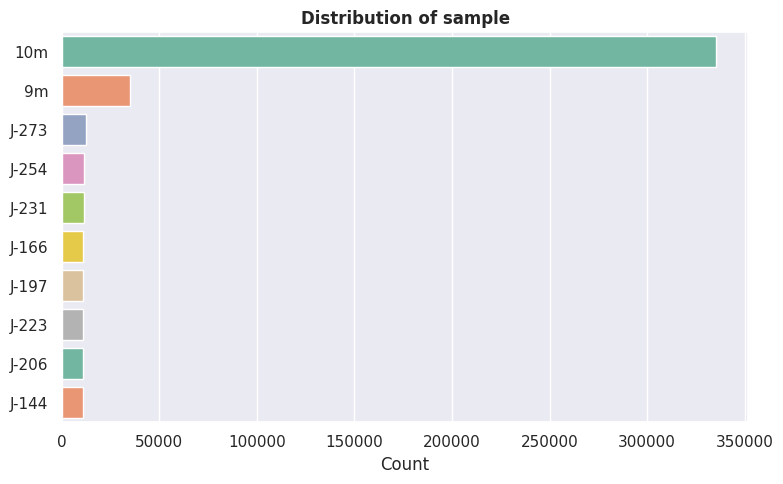

In [10]:
fig, axes = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=df_mhd_ch4_raw,
    y='sample',
    order = df_mhd_ch4_raw['sample'].value_counts().index[:10],
    palette='Set2'
)
axes.set_title(f'Distribution of sample', fontsize=12, fontweight='bold')
axes.set_xlabel('Count')
axes.set_ylabel('')

plt.tight_layout()
plt.show()

====== 0523 ends =======

=============== 0525 starts==============

0526 feature engineering
create new feature: label( show whether good or bad data)

In [11]:
df_mhd_ch4_v1 =df_mhd_ch4_raw.copy()

add new feature: label1
definition: one of the flag_ht or flag_a is not empty(space) -> 1 (error)
                both space -> 0 (correct)

In [12]:
# convert nan values into " "(space)-> means good values
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":1, 
          "A":1
        }
df_mhd_ch4_v1 ["CH4_flag"] = df_mhd_ch4_v1 ["CH4_flag"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].fillna(" ")
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].fillna(" ")

In [13]:
# convert flag to 0/1
df_mhd_ch4_v1 ["CH4_flag_ht"] = df_mhd_ch4_v1 ["CH4_flag_ht"].map(mapping)
df_mhd_ch4_v1 ["CH4_flag_a"] = df_mhd_ch4_v1 ["CH4_flag_a"].map(mapping)


In [14]:
df_mhd_ch4_v1 ['label'] = ((df_mhd_ch4_v1 ["CH4_flag_ht"]==1) | (df_mhd_ch4_v1 ["CH4_flag_a"]==1)).astype(int)
df_mhd_ch4_v1 ['label']

0         1
1         1
2         1
3         0
4         1
         ..
817950    0
817951    0
817952    0
817953    1
817954    0
Name: label, Length: 817955, dtype: int64

In [15]:
df_mhd_ch4_v1["CH4_flag"] 

0          
1          
2          
3          
4          
         ..
817950    A
817951    A
817952    A
817953    A
817954    A
Name: CH4_flag, Length: 817955, dtype: object

In [16]:
df_mhd_ch4_v2 = df_mhd_ch4_v1.copy()

df_mhd_ch4_v2

In [17]:
pd.set_option('display.max_columns', None)
df_mhd_ch4_v2.iloc[[185]]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
185,940219,102700,cal1060,G-024,G-024,1,0.0,40.01,23.16,NaN,846.8,1058.3,NaN,751.2,95.2,7.51,205489.0,1651923.0,1.0,82.6,130.2,30872.0,30727.0,0.92736,1.00177,0.92736,1.3073,1.4122,1.0901,0.92736,1.00177,0.92736,1569.54,1695.49,1692.49,3.18,NaN,1692.489,0,0,,,0


In [18]:
df_mhd_ch4_v2.iloc[[-1]]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
817954,260518,81300,std,J-286,J-286,3,0.0,40.0,22.23,NaN,813.3,752.09,NaN,752.0,82.0,5.46,204547.0,1177596.0,0.43,73.0,115.2,75876.0,68601.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.873,NaN,2015.923,0,0,A,,0


df_mhd_ch4[''].corr()

 0526 dataset checked no error 

In [19]:
df_mhd_ch4_v2.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,label
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,0,0,,,0
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,,,1


In [20]:
df_mhd_ch4_v2.isna().sum().sort_values(ascending=False)

lab_temp           817954
ploop              817954
CH4_std_rep        471913
tamb               112285
tmod               112284
CH4_C               59835
CH4_Rl              58674
CH4_R               58674
CH4_C_ht            52743
CH4_norm_ht         51247
CH4_Rl_ht           51247
CH4_R_ht            51247
CH4_norm_a          51247
CH4_norm_w          51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21817
pamb                 2404
pflow                2402
psamp                2330
CH4_start_level      1590
CH4_start_time       1590
CH4_w                1590
CH4_ht               1590
CH4_area             1590
CH4_end_level        1590
CH4_rt               1590
CH4_end_time         1590
CH4_skew             1590
port                    0
time                    0
date                    0
type                    0
ht                      0
sample                  0
standard                0
CH4_Cstd                0
CH4_flag_ht 

define which features sould quite( too much nan)

**Remove the Nan values (that almost all Nan)** 

In [21]:
cols_to_drop=['lab_temp','CH4_flag_p','ploop','CH4_flag' ]
df_mhd_ch4_v3 = df_mhd_ch4_v2.drop(columns=cols_to_drop)

df_mhd_ch4_v3

In [22]:
df_mhd_ch4_v3.isna().sum().sort_values(ascending=False)

CH4_std_rep        471913
tamb               112285
tmod               112284
CH4_C               59835
CH4_R               58674
CH4_Rl              58674
CH4_C_ht            52743
CH4_norm_ht         51247
CH4_norm_w          51247
CH4_norm_a          51247
CH4_R_ht            51247
CH4_Rl_ht           51247
CH4_C_a             50993
CH4_Rl_a            49492
CH4_R_a             49492
CH4_std_stdev       21817
pamb                 2404
pflow                2402
psamp                2330
CH4_skew             1590
CH4_area             1590
CH4_w                1590
CH4_start_level      1590
CH4_rt               1590
CH4_end_level        1590
CH4_start_time       1590
CH4_end_time         1590
CH4_ht               1590
type                    0
date                    0
time                    0
ht                      0
port                    0
standard                0
sample                  0
CH4_Cstd                0
CH4_flag_ht             0
CH4_flag_a              0
label       

In [23]:
df_mhd_ch4_v3['type'].value_counts()

type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal30           6
cal225          6
cal300          6
cal120          6
cal60           6
cal180          6
cal90           6
cal45           4
cal15           3
cal165          3
cal135          3
cal75           3
cal105          3
cal250          3
cal200          3
cal500          3
-               1
Name: count, dtype: int64

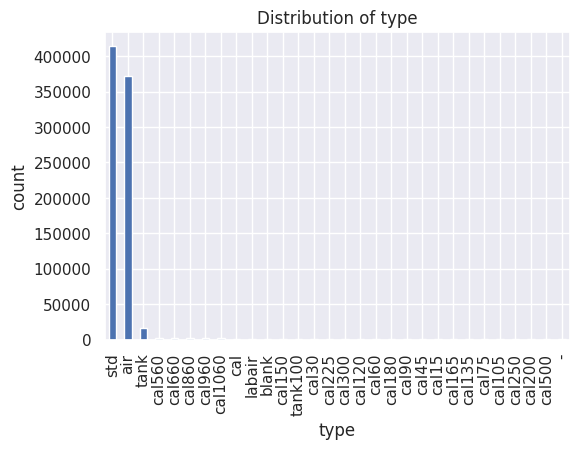

In [24]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['type'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of type")
plt.xlabel('type')
plt.ylabel('count')
plt.show()

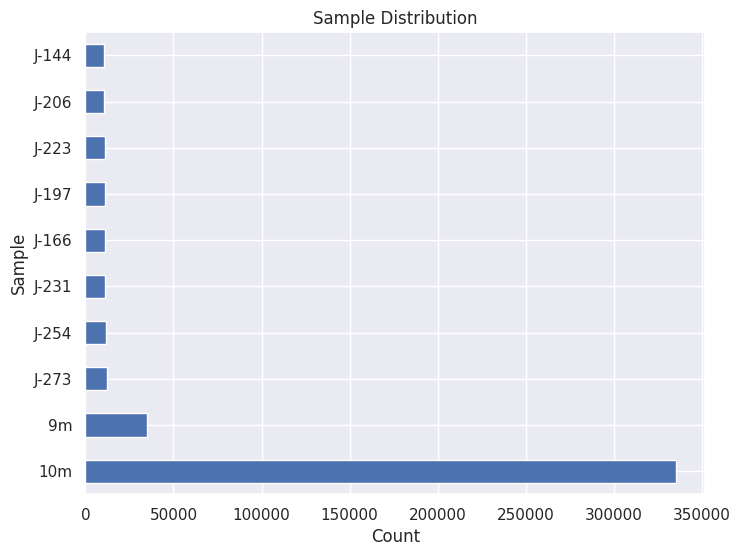

In [25]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['sample'].value_counts().head(10).plot(
    kind='barh',
    figsize=(8,6)
)
plt.title("Sample Distribution")
plt.xlabel('Count')
plt.ylabel('Sample')
plt.show()
# too many -> only show first 10
#===================
# 10m, 9m -> air
# other-> std, cal

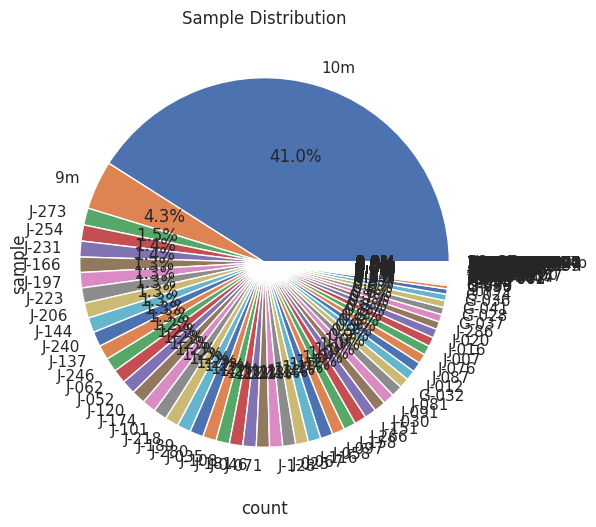

In [26]:
df_mhd_ch4_v3['sample'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sample Distribution')
plt.xlabel('count')
plt.ylabel('sample')
plt.show()

The pie chart show that the 10m and 9m accounts most data
-> 10m, 9m means -> air

In [27]:
pd.set_option('display.max_rows', None)
df_mhd_ch4_v3['sample'].value_counts()

sample
10m             335171
9m               34964
J-273            12205
J-254            11469
J-231            11315
J-166            11009
J-197            10937
J-223            10877
J-206            10854
J-144            10735
J-240            10665
J-137            10426
J-246            10029
J-062             9962
J-052             9915
J-120             9850
J-174             9825
J-101             9771
J-218             9768
J-189             9760
J-280             9693
J-035             9662
J-108             9609
J-181             9603
J-046             9550
J-071             9416
J-128             9336
J-025             9260
J-067             9078
J-116             9078
J-058             8931
J-097             8871
J-158             8699
J-266             8552
J-151             8323
J-030             8229
J-091             8217
J-081             7916
G-032             7182
J-012             7166
J-087             7064
J-076             6944
J-007             6790
J-01

type ->  std and correponding sample

In [28]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='std', 'sample'].unique()

array(['G-024', 'G-028', 'G-032', 'CO-001', 'G-036', 'G-037', 'G-041',
       'J-007', 'J-012', 'J-016', 'J-020', 'J-025', 'J-030', 'J-035',
       'J-046', 'J-052', 'J-058', 'J-062', 'J-067', 'J-071', 'J-076',
       'J-081', 'J-087', 'J-091', 'J-097', 'J-101', 'BOC-49177', 'J-108',
       'J-116', 'H-108', 'J-120', 'H-144', 'J-128', 'J-137', 'J-144',
       'G-055', 'J-151', 'J-158', 'J-166', 'J-174', 'J-181', 'J-189',
       'J-197', 'H-095', 'J-206', 'H-344', 'J-218', 'J-223', 'J-231',
       'J-240', 'J-246', 'J-254', 'J-266', 'J-273', 'H-055', 'D211555',
       'J-280', 'J-286'], dtype=object)

type ->  air and correponding sample

In [29]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='air', 'sample'].unique()

array(['10m', '10m_MB158E-p', 'Sib1_4', '3m', '9m'], dtype=object)

type ->  tank and correponding sample

In [30]:
df_mhd_ch4_v3.loc[df_mhd_ch4_v3['type']=='tank', 'sample'].unique()


array(['BOC-49177', 'G-024', 'S-003', 'G-032', 'S-004', 'H-005', 'H-004',
       'H-006D', 'H-006', 'MRF-S', 'MRF-D', 'H-003', 'CO-001',
       'CLM-005557', 'G-036', 'BOC-49177D', 'CO-001D', 'G-037', 'H-007',
       'S160-H09', 'S160-H05', 'HFD-005', 'H-008D', 'H-008', 'G-041',
       'CO1', 'J-007', 'H-009', 'M-001', 'M-002', 'H-009D', 'H-010',
       'H-011', 'J-012', 'M-005', 'U.Leeds', 'J-016', 'H-012', 'Bris1',
       'G-050', 'G-055', 'H-013', 'H-014', 'M-006', 'B-003', 'M-007',
       'J-020', 'H-015', 'BRW1', 'ALM064959', 'HD-007', 'MD-007-6',
       'MD-007-4', 'MD-007-3', 'MD-007-2', 'J-025', 'H-016', 'FA01469',
       'FA01467', 'FA01477', 'M-008', 'G-064', 'H-017', 'H-018', 'M-009',
       'H-019', 'H-020', 'J-030', 'CA03255', 'CA03233', 'CA03229',
       'CA03220', 'CA02964', 'UAN990635', 'UAN990624', 'UAN990621',
       'UAN990629', 'UAN990630', 'UAN990622', 'UAN990625', 'UAN990620',
       'UAN990634', 'UAN990632', 'UAN990631', 'UAN990619', 'UAN990636',
       'UAN99062

Distribution of port

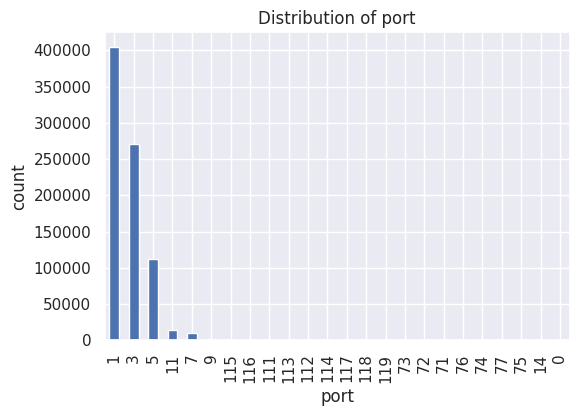

In [31]:
import matplotlib.pyplot as plt 
df_mhd_ch4_v3['port'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Distribution of port")
plt.xlabel('port')
plt.ylabel('count')
plt.show()

Port 1, 3, 5 are the most used ones

# instrument states

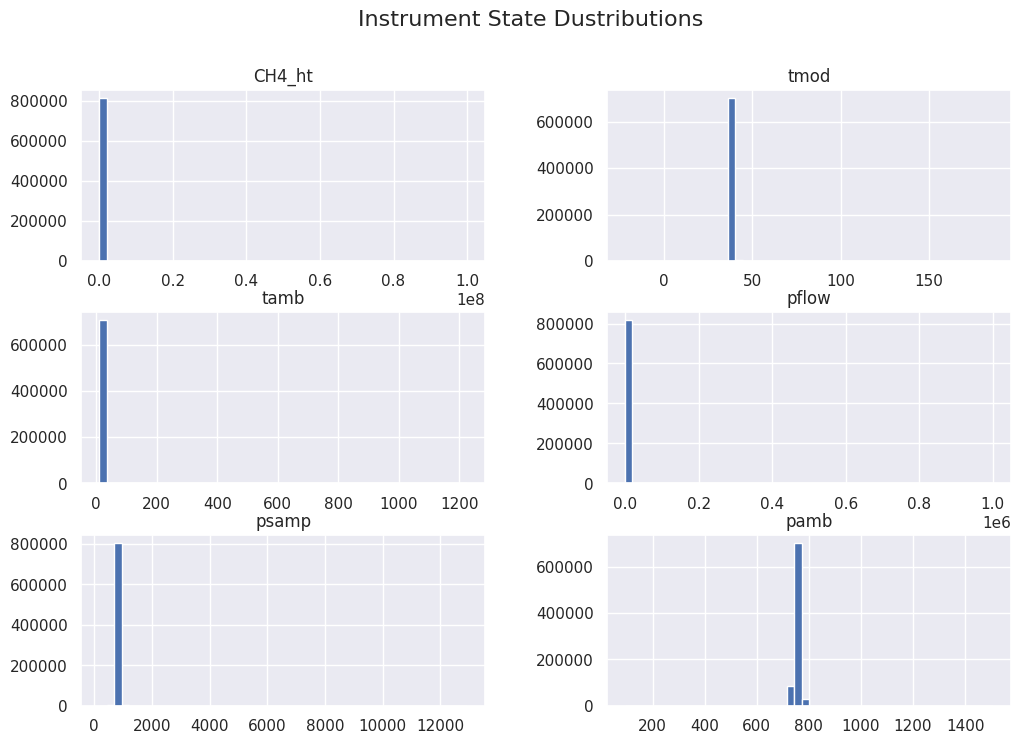

In [32]:
import matplotlib.pyplot as plt
#'temp', 'ploop' nan too many removed
cols = ['CH4_ht', 'tmod',  'tamb',  'pflow' , 'psamp', 'pamb']

df_mhd_ch4_v3[cols].hist(figsize=(12,8), bins=50)
plt.suptitle("Instrument State Dustributions", fontsize=16)
plt.show()

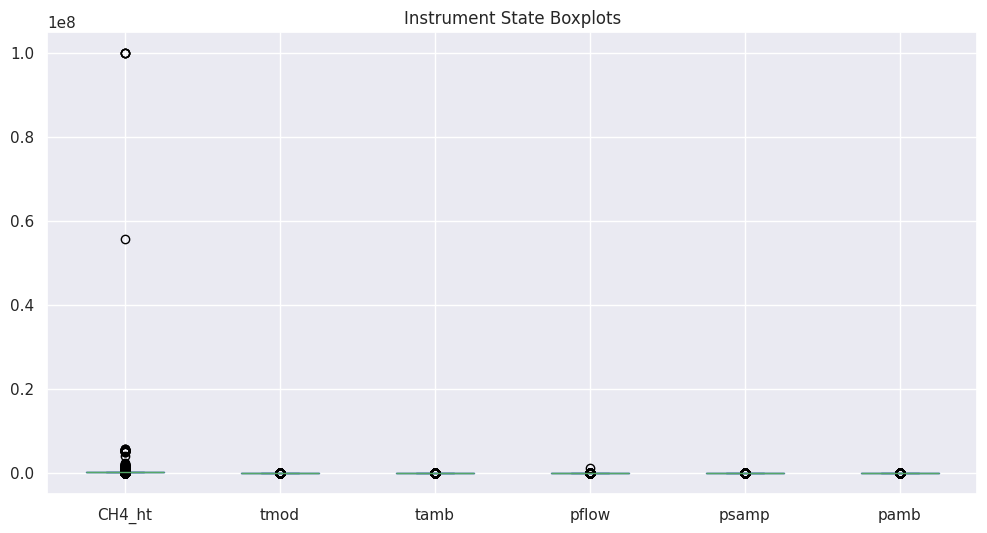

In [33]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

**Explore instrument states by labels**



#not many useful insights -> convert it into markdown**
import seaborn as sns

for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f"{c} by label")
    plt.show()

pflow has a data point at nearly 100000, psamp has one at 10000?
try to move the 100000 one

In [34]:
df_mhd_ch4_v3[df_mhd_ch4_v3['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label
128952,990406,32600,std,J-030,J-030,1,0.0,40.0,20.27,999999.0,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,1,1,1


In [35]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']>=8000]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
128952,990406,32600,std,J-030,J-030,1,0.0,40.0,20.27,NaN,999999.0,NaN,NaN,NaN,101.6,7.62,143978.0,1179415.0,1.08,89.2,136.2,20326.0,20306.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.736,NaN,1839.437,F,F,,


In [36]:
df_mhd_ch4_raw[df_mhd_ch4_raw['psamp']>=10000]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
323309,61209,50400,std,J-097,J-097,1,0.0,40.0,22.64,NaN,810.3,12922.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.355,NaN,1861.378,F,F,,


flag_ht and flag_a were all bad
-> back check -> F flag

the psamp 12922-> flag h and flag a -> F

In [37]:
df_mhd_ch4_v3[cols].describe()

,CH4_ht,tmod,tamb,pflow,psamp,pamb
count,8.163650e+05,705671.000000,705670.000000,815553.000000,815625.000000,815551.000000
mean,1.539311e+05,40.004814,20.890968,813.148846,757.492706,756.596820
std,2.334500e+05,0.225875,2.302447,1106.652773,30.281805,9.888484
min,0.000000e+00,-22.000000,10.570000,159.900000,182.710000,94.600000
25%,1.429670e+05,40.000000,19.780000,801.100000,750.570000,750.700000
50%,1.522090e+05,40.000000,20.650000,809.700000,757.590000,757.600000
75%,1.683100e+05,40.000000,21.650000,818.900000,763.550000,763.400000
max,1.000000e+08,186.000000,1225.000000,999999.000000,12922.000000,1505.900000


**drop extreme values from pflow and psamp**

In [38]:
df_mhd_ch4_drop = df_mhd_ch4_v3[(df_mhd_ch4_v3['psamp']<=10000) & (df_mhd_ch4_v3['pflow']<=90000)]

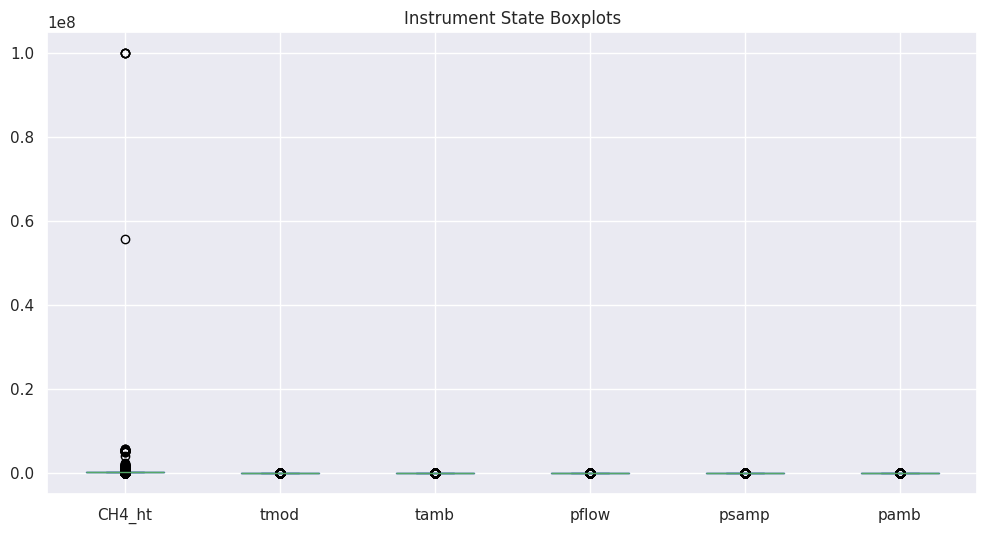

In [39]:
df_mhd_ch4_drop[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

# Explore peak features


In [40]:
cols = ['CH4_rt', 'CH4_w', "CH4_ht","CH4_area", "CH4_skew"]
df_mhd_ch4_v3[cols].describe()

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew
count,816365.000000,816365.000000,8.163650e+05,8.163650e+05,816365.000000
mean,96.536946,7.952014,1.539311e+05,1.356756e+06,1.045417
std,14.293784,80.149120,2.334500e+05,1.994460e+06,0.203050
min,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,96.400000,7.700000,1.429670e+05,1.237550e+06,1.040000
50%,98.600000,7.870000,1.522090e+05,1.363766e+06,1.070000
75%,100.600000,8.380000,1.683100e+05,1.484507e+06,1.100000
max,166.600000,72415.000000,1.000000e+08,1.000000e+09,82.800000


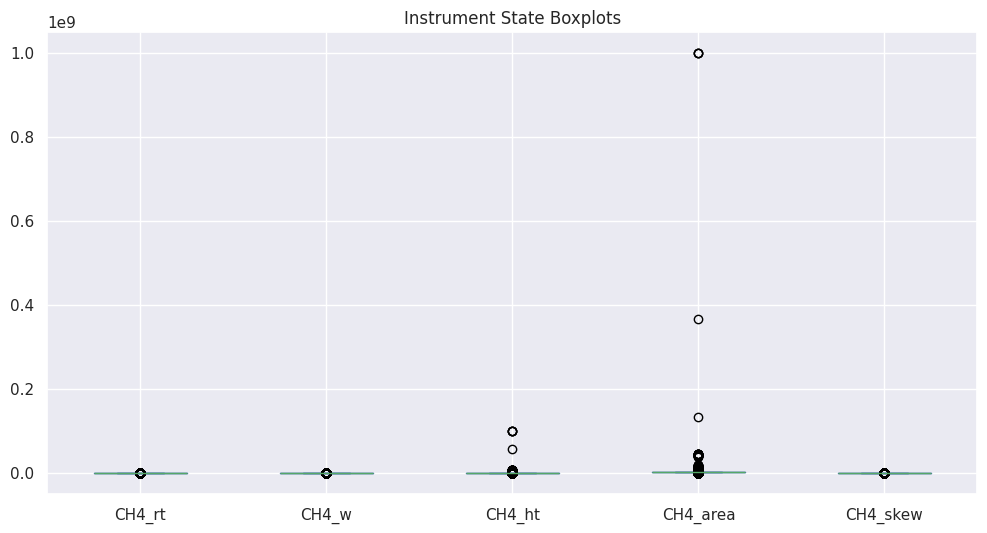

In [41]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Instrument State Boxplots")
plt.show()

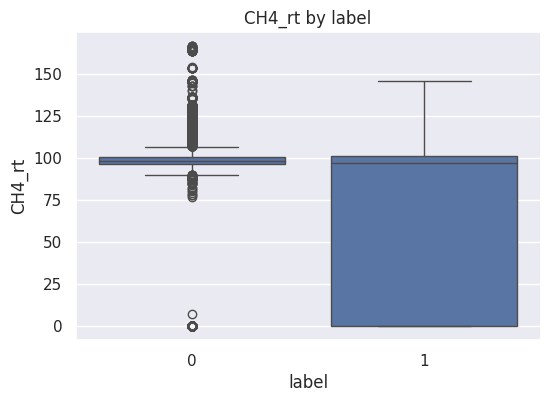

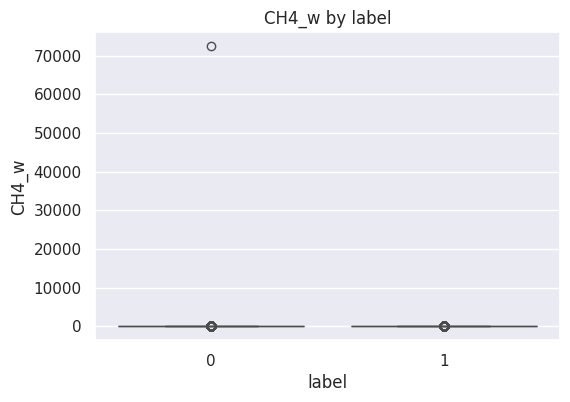

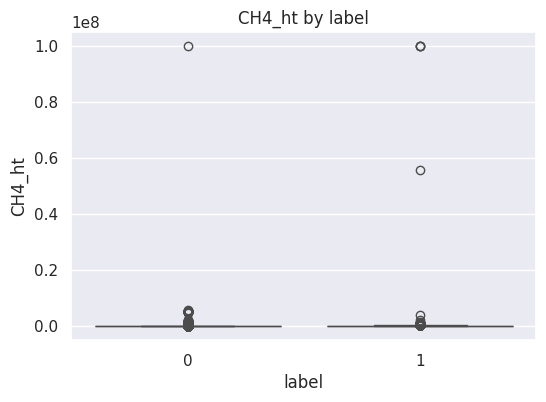

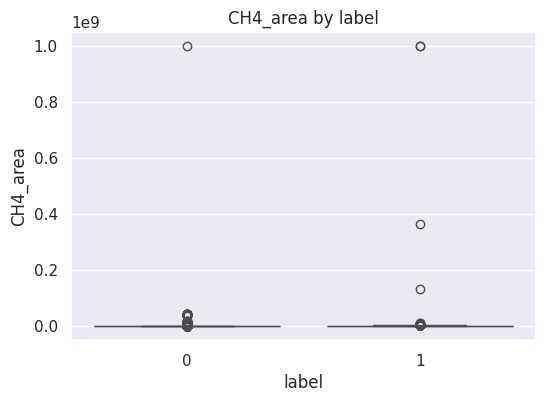

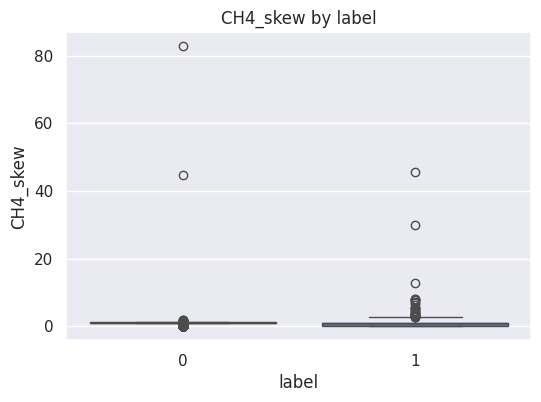

In [42]:
import seaborn as sns

for c in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=c, data=df_mhd_ch4_v3)
    plt.title(f"{c} by label")
    plt.show()

rt, w min = 0

explore it

In [43]:
df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_rt']==0].head(20)
# head(1000) can see tank

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
10,940216,202300,air,10m,G-024,3,10.0,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
11,940216,204300,air,10m,G-024,3,10.0,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,


In [44]:
(df_mhd_ch4_raw['CH4_rt']==0).sum()

np.int64(16699)

rt == 0 -> most F flag

but if it's 'cal' type -> Nan

tank is also ->nan

In [45]:
df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_w']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
10,940216,202300,air,10m,G-024,3,10.0,40.00,33.17,NaN,846.1,759.83,NaN,760.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,
11,940216,204300,air,10m,G-024,3,10.0,40.00,33.05,NaN,846.3,759.91,NaN,759.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,


In [46]:
(df_mhd_ch4_raw['CH4_w']==0).sum()

np.int64(16706)

In [47]:
((df_mhd_ch4_raw['CH4_w']==0) & (df_mhd_ch4_raw['CH4_flag_ht']!=" " ) & (df_mhd_ch4_raw['CH4_flag_a']!=" ")).sum()

np.int64(14754)

In [48]:
((df_mhd_ch4_raw['CH4_rt']==0) & (df_mhd_ch4_raw['CH4_flag_ht']!=" " ) & (df_mhd_ch4_raw['CH4_flag_a']!=" ")).sum()

np.int64(14749)

In [49]:
((df_mhd_ch4_raw['CH4_rt']==0) & (df_mhd_ch4_raw['CH4_flag_ht']!=" " )).sum()

np.int64(14749)

w==0 -> 16725 data

rt = 0 -> 16699 data

==========

explore the data where rt = 0 but w is not 0

In [50]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_w']==0) & (df_mhd_ch4_raw['CH4_rt']!=0)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10.0,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,,,,
135153,990706,112700,std,J-030,J-030,1,0.0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,,
218278,21015,162000,air,10m,J-062,3,10.0,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,,
311839,60619,174000,std,J-091,J-091,1,0.0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,
517178,140618,120400,std,J-166,J-166,3,0.0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,,
655747,191128,164400,air,10m,J-223,1,10.0,40.00,19.36,NaN,796.5,749.39,NaN,749.3,80.4,0.0,0.0,0.0,0.19,73.0,101.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.921,NaN,1922.093,F,F,,
817947,260518,55300,air,9m,J-286,1,9.0,40.00,22.20,NaN,808.5,752.24,NaN,752.2,76.8,0.0,0.0,0.0,0.53,73.0,98.6,99999.0,60611.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.545,NaN,2015.923,,,A,


In [51]:
((df_mhd_ch4_raw['CH4_w']==0) & (df_mhd_ch4_raw['CH4_rt']!=0)).sum()

np.int64(7)

In [52]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_w']==0) & (df_mhd_ch4_raw['CH4_rt']!=0)]


,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
2090,940322,93400,air,10m,G-024,3,10.0,40.01,25.09,NaN,836.9,754.15,NaN,NaN,90.2,0.0,0.0,0.0,0.76,83.6,90.8,28394.0,44771.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.190,NaN,1692.489,,,,
135153,990706,112700,std,J-030,J-030,1,0.0,40.00,22.28,NaN,817.3,760.05,NaN,760.1,89.2,0.0,0.0,0.0,1.32,87.8,110.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.260,NaN,1839.437,F,F,,
218278,21015,162000,air,10m,J-062,3,10.0,40.00,20.66,NaN,812.0,752.05,NaN,752.1,105.4,0.0,0.0,0.0,1.44,104.0,126.8,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.654,NaN,1849.264,F,F,,
311839,60619,174000,std,J-091,J-091,1,0.0,40.00,20.30,NaN,809.1,756.68,NaN,756.8,98.6,0.0,0.0,0.0,1.25,93.0,123.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.441,NaN,1851.219,F,F,A,
517178,140618,120400,std,J-166,J-166,3,0.0,40.00,24.62,NaN,808.6,769.71,NaN,769.6,87.4,0.0,0.0,0.0,0.51,81.6,108.2,17233.0,10466.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.236,NaN,1883.393,F,F,,
655747,191128,164400,air,10m,J-223,1,10.0,40.00,19.36,NaN,796.5,749.39,NaN,749.3,80.4,0.0,0.0,0.0,0.19,73.0,101.6,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.921,NaN,1922.093,F,F,,
817947,260518,55300,air,9m,J-286,1,9.0,40.00,22.20,NaN,808.5,752.24,NaN,752.2,76.8,0.0,0.0,0.0,0.53,73.0,98.6,99999.0,60611.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.545,NaN,2015.923,,,A,


In [53]:
df_mhd_ch4_raw[df_mhd_ch4_raw['pflow']==0].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p


**Summary of w and rt**

one of them is zero means a potentially error

make them as labels?

**ch4_ht.1 and area**
skew can be an potential important QC feature(much obvious difference between 0 and 1)

CH4_ht.1 : label 1, 2 obvious extreme values(0ver 0.95*1e6)

CH4_area : label 1, 2 obvious extreme values(0ver 0.9*1e7)

In [54]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_ht']>= 0.95*1e6)&(df_mhd_ch4_v3['label']==1)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
68458,961026,125800,std,J-007,J-007,1,0.0,40.00,20.71,NaN,837.4,754.70,NaN,754.7,106.0,1.86,1359665.0,4944932.0,1.09,97.2,136.8,10198.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.883,NaN,1814.104,F,F,,
113726,980810,162900,std,J-025,J-025,1,0.0,40.00,21.92,NaN,812.1,758.90,NaN,758.9,106.0,1.07,55722112.0,133164408.0,1.00,73.0,110.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.180,NaN,1836.745,*,*,,
212945,20801,113900,air,10m,J-062,3,10.0,40.00,21.43,NaN,802.5,756.05,NaN,756.4,110.2,2.16,1266821.0,5429058.0,2.15,105.2,125.4,10325.0,26921.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.251,NaN,1849.264,F,F,,
218275,21015,152000,std,J-062,J-062,1,0.0,40.01,20.96,NaN,802.9,751.93,NaN,751.9,111.4,1.34,2354322.0,9881074.0,1.28,100.0,119.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.687,NaN,1849.264,F,F,,
307646,60421,143300,air,10m,J-091,3,10.0,40.01,21.84,NaN,816.0,762.79,NaN,762.7,110.4,1.92,3996082.0,8171550.0,1.75,107.2,116.0,28728.0,22466.0,27.47151,7.0957,NaN,27.4749,7.0966,0.2645,27.47151,7.0957,NaN,50855.8,13135.7,NaN,3.600,NaN,1851.219,F,F,,
377766,90121,112300,tank,499310,J-116,11,0.0,40.00,19.52,NaN,773.8,737.68,NaN,737.2,90.4,34.72,99999999.0,999999999.0,45.48,79.4,471.8,10400.0,38773.0,454.43320,1907.0630,NaN,454.6660,1908.0400,4.1867,454.43320,1907.0630,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,,
661957,200227,101200,tank,P5-EF38PMQ,J-231,11,0.0,40.00,20.24,NaN,810.0,753.18,NaN,753.3,99.2,23.11,99999999.0,999999999.0,29.94,88.2,271.4,35149.0,52675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,F,F,,
706587,211201,105500,labair,labair,J-246,9,0.0,40.00,22.73,NaN,415.3,727.16,NaN,755.4,97.2,2.33,99999999.0,365039744.0,2.05,81.2,163.6,24715.0,30803.0,692.23980,250.8062,NaN,666.4740,241.4710,0.3033,692.23980,250.8062,NaN,1328418.0,481301.0,NaN,4.826,NaN,1919.014,F,F,,
758537,240107,221300,std,J-266,J-266,5,0.0,40.00,20.11,NaN,NaN,NaN,NaN,NaN,101.8,9.70,1170588.0,12268818.0,1.08,85.2,151.2,25655.0,26863.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.925,NaN,1996.36,F,F,A,


In [55]:
df_mhd_ch4_raw[(df_mhd_ch4_raw['CH4_area']>= 0.9*1e7)&(df_mhd_ch4_v3['label']==1)].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p
113726,980810,162900,std,J-025,J-025,1,0.0,40.00,21.92,NaN,812.1,758.90,NaN,758.9,106.0,1.07,55722112.0,133164408.0,1.00,73.0,110.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.180,NaN,1836.745,*,*,,
218275,21015,152000,std,J-062,J-062,1,0.0,40.01,20.96,NaN,802.9,751.93,NaN,751.9,111.4,1.34,2354322.0,9881074.0,1.28,100.0,119.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.687,NaN,1849.264,F,F,,
377766,90121,112300,tank,499310,J-116,11,0.0,40.00,19.52,NaN,773.8,737.68,NaN,737.2,90.4,34.72,99999999.0,999999999.0,45.48,79.4,471.8,10400.0,38773.0,454.4332,1907.0630,NaN,454.666,1908.040,4.1867,454.4332,1907.0630,NaN,858205.0,3601524.0,NaN,4.297,NaN,1888.518,F,F,,
661957,200227,101200,tank,P5-EF38PMQ,J-231,11,0.0,40.00,20.24,NaN,810.0,753.18,NaN,753.3,99.2,23.11,99999999.0,999999999.0,29.94,88.2,271.4,35149.0,52675.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,F,F,,
706587,211201,105500,labair,labair,J-246,9,0.0,40.00,22.73,NaN,415.3,727.16,NaN,755.4,97.2,2.33,99999999.0,365039744.0,2.05,81.2,163.6,24715.0,30803.0,692.2398,250.8062,NaN,666.474,241.471,0.3033,692.2398,250.8062,NaN,1328418.0,481301.0,NaN,4.826,NaN,1919.014,F,F,,
758537,240107,221300,std,J-266,J-266,5,0.0,40.00,20.11,NaN,NaN,NaN,NaN,NaN,101.8,9.70,1170588.0,12268818.0,1.08,85.2,151.2,25655.0,26863.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.925,NaN,1996.36,F,F,A,


**Findings**

peak fitting error so use the maximum as error code?

# Calibration/Normalization EDA

In [56]:
cols = ['CH4_Rl_ht', 'CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R' ]
df_mhd_ch4_v3[cols].describe()

,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R
count,766708.000000,768463.000000,759281.000000,766708.000000,766708.000000,766708.000000,766708.000000,768463.000000,759281.000000
mean,1.010615,1.012102,1.007994,1.011424,1.013123,0.997908,1.010615,1.012102,1.009119
std,0.970973,2.203280,0.214878,0.945243,2.204825,0.050597,0.970973,2.203280,1.003149
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.998330,0.998610,0.998430,0.998400,0.998600,0.998900,0.998330,0.998610,0.998430
50%,1.000620,1.000520,1.000600,1.000700,1.000600,1.000000,1.000620,1.000520,1.000600
75%,1.006980,1.006490,1.006740,1.007300,1.007300,1.001100,1.006980,1.006490,1.006740
max,692.239800,1907.063000,35.119560,666.474000,1908.040000,4.186700,692.239800,1907.063000,854.830000


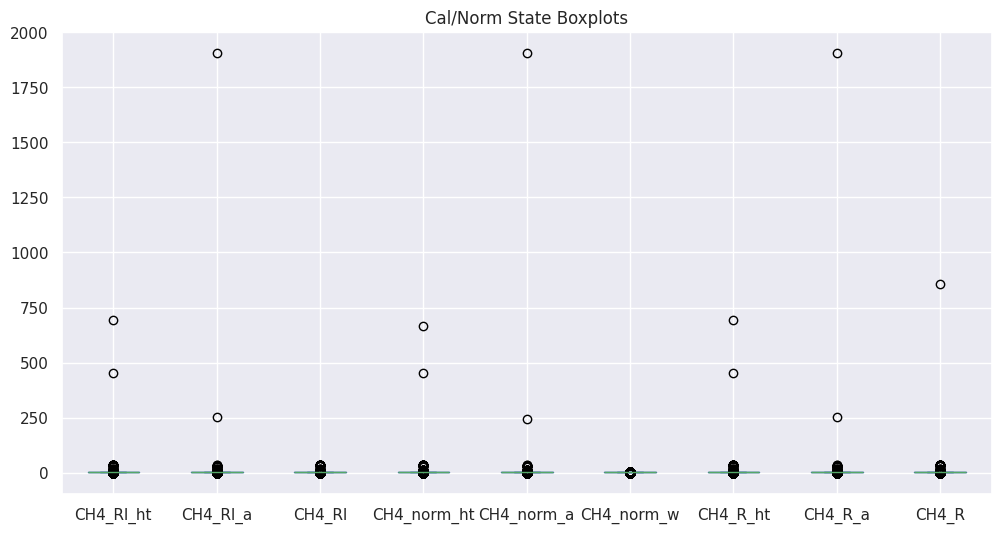

In [57]:
df_mhd_ch4_v3[cols].plot(kind='box', figsize=(12,6))
plt.title("Cal/Norm State Boxplots")
plt.show()

CH4_Rl_ht: 2 extreme values , >10?
CH4_Rl_a: 2 extreme values, > 10 ?
CH4_norm_ht: 2 extreme values, > 400
Ch4_norm_a: 2 extreme values, > 10?
CH4_R_ht: 2 extreme values > 10,
CH4_R_a: 2 extreme, >10

df_mhd_ch4_raw[df_mhd_ch4_raw['CH4_Rl_ht'] > 10].head(20)

In [58]:
for c in cols:
    if c =='CH4_norm_ht':
        print(f'{c}:extreme values:\n', df_mhd_ch4_raw[df_mhd_ch4_raw[c] > 400].head(20),'\n')
    else:
        print(f'{c}:extreme values:\n', df_mhd_ch4_raw[df_mhd_ch4_raw[c] > 10].head(20), '\n')
    print('==================================================')


CH4_Rl_ht:extreme values:
          date    time    type sample standard  port   ht  tmod  tamb  \
276979  50203  112600  labair  H-070    J-081    11  0.0   NaN   NaN   
277117  50205  100700  labair  H-070    J-081    11  0.0   NaN   NaN   
277139  50205  172700  labair  H-070    J-081    11  0.0   NaN   NaN   
277161  50206    4700  labair  H-070    J-081    11  0.0   NaN   NaN   
277614  50212  101000  labair  H-070    J-081    11  0.0   NaN   NaN   
277636  50212  173000  labair  H-070    J-081    11  0.0   NaN   NaN   
277658  50213    5000  labair  H-070    J-081    11  0.0   NaN   NaN   
278111  50219  101400  labair  H-070    J-081    11  0.0   NaN   NaN   
278133  50219  173400  labair  H-070    J-081    11  0.0   NaN   NaN   
278155  50220    5400  labair  H-070    J-081    11  0.0   NaN   NaN   
278608  50226  101700  labair  H-070    J-081    11  0.0   NaN   NaN   
278630  50226  173700  labair  H-070    J-081    11  0.0   NaN   NaN   
278652  50227    5700  labair  H-070 

Are all :
    377766 
    706587

same results with  CH4_ht.1 extreme CH4_area extreme.
CH4_RI no extreme -> because is NAN in both 377766, and 706587
 => same as CH4_R (NAN)

notice: rt and w are not 0.0
------------
Cal/Norm worng -> peak fitting error -> ht/area error -> flag F ?
-----------
maybe the error are two types?
peak fitting error 
and 
calibration error
( has peak but)


**convert time to plot time-series data**

In [59]:
df_mhd_ch4_time = df_mhd_ch4_v3.copy()
df_mhd_ch4_time['date'] = df_mhd_ch4_time['date'].astype(str).str.zfill(6)
df_mhd_ch4_time['time'] = df_mhd_ch4_time['time'].astype(str).str.zfill(6)

df_mhd_ch4_time['datetime_str'] = df_mhd_ch4_time['date'] + df_mhd_ch4_time['time']

df_mhd_ch4_time['datetime'] = pd.to_datetime(df_mhd_ch4_time['datetime_str'], format='%y%m%d%H%M%S')

df_mhd_ch4_time.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,841.9,761.10,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216142900,1994-02-16 14:29:00
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,840.4,761.07,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216144900,1994-02-16 14:49:00
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,839.4,760.99,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216150900,1994-02-16 15:09:00
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,839.6,760.96,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,0,0,0,940216152900,1994-02-16 15:29:00
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,845.4,760.72,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216180000,1994-02-16 18:00:00
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,846.2,760.60,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216182000,1994-02-16 18:20:00
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,846.3,760.57,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216184000,1994-02-16 18:40:00
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,846.5,760.45,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216190000,1994-02-16 19:00:00
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,846.6,760.34,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216192000,1994-02-16 19:20:00
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,844.8,760.35,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,1,1,940216194000,1994-02-16 19:40:00


/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


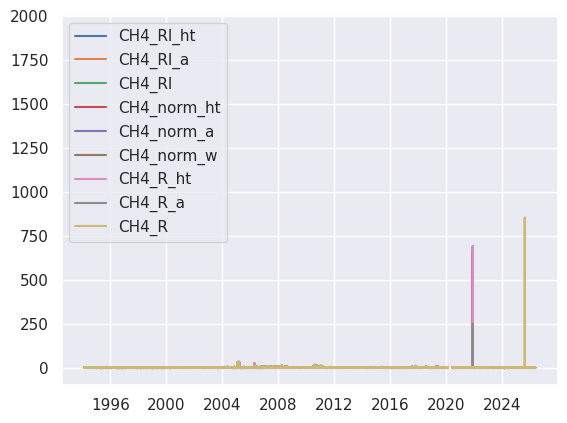

In [60]:
for c in cols:
    plt.plot(df_mhd_ch4_time['datetime'], df_mhd_ch4_time[c], label=c)

plt.legend()
plt.show()

In [61]:
df_mhd_ch4_time[(df_mhd_ch4_time['datetime']>'2020-01-01')].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime
657883,200101,001800,std,J-223,J-223,3,0.0,40.0,20.33,816.3,768.26,768.1,99.8,6.87,136408.0,1099702.0,0.93,86.4,137.4,26348.0,26657.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.277,NaN,1922.093,0,0,0,200101001800,2020-01-01 00:18:00
657884,200101,005800,std,J-223,J-223,3,0.0,40.0,20.72,815.9,767.80,767.8,99.8,6.87,136335.0,1099447.0,0.93,86.4,137.6,26558.0,26794.0,1.00129,1.00162,1.00129,1.0013,1.0016,0.9999,1.00129,1.00162,1.00129,1924.58,1925.21,1924.58,5.334,NaN,1922.093,0,0,0,200101005800,2020-01-01 00:58:00
657885,200101,011800,air,10m,J-223,1,10.0,40.0,20.69,814.5,767.48,767.5,99.8,6.86,142144.0,1145919.0,0.93,86.4,137.6,26470.0,26728.0,1.04434,1.04419,1.04434,1.0442,1.0441,1.0001,1.04434,1.04419,1.04434,2007.32,2007.03,2007.32,5.349,5.586,1922.093,0,0,0,200101011800,2020-01-01 01:18:00
657886,200101,013800,std,J-223,J-223,3,0.0,40.0,20.77,815.3,767.33,767.2,99.8,6.86,135910.0,1095634.0,0.93,86.4,137.4,26412.0,26687.0,0.99874,1.00132,0.99874,0.9988,1.0013,0.9991,0.99874,1.00132,0.99874,1919.67,1924.63,1919.67,5.386,NaN,1922.093,0,0,0,200101013800,2020-01-01 01:38:00
657887,200101,015800,air,10m,J-223,1,10.0,40.0,20.61,814.1,767.04,766.9,100.0,6.89,141360.0,1144588.0,0.90,86.4,137.8,26594.0,26839.0,1.04050,1.04797,1.04050,1.0404,1.0479,1.0040,1.04050,1.04797,1.04050,1999.93,2014.30,1999.93,5.386,5.604,1922.093,0,0,0,200101015800,2020-01-01 01:58:00
657888,200101,021800,std,J-223,J-223,3,0.0,40.0,20.45,814.7,766.84,766.8,100.0,6.87,135823.0,1088894.0,0.91,86.8,137.6,27013.0,26824.0,0.99686,0.98853,0.99686,0.9964,0.9881,0.9985,0.99686,0.98853,0.99686,1916.07,1900.04,1916.07,5.370,NaN,1922.093,0,0,0,200101021800,2020-01-01 02:18:00
657889,200101,023800,air,10m,J-223,1,10.0,40.0,20.66,811.8,766.74,766.7,100.0,6.89,144405.0,1169116.0,0.90,86.4,138.0,26456.0,26789.0,1.05998,1.06440,1.05998,1.0597,1.0641,1.0005,1.05998,1.06440,1.05998,2037.39,2045.88,2037.39,5.370,5.692,1922.093,0,0,0,200101023800,2020-01-01 02:38:00
657890,200101,025800,std,J-223,J-223,3,0.0,40.0,20.72,814.9,767.04,766.8,100.0,6.90,136714.0,1108434.0,0.90,86.6,137.8,26524.0,26787.0,1.00475,1.01478,1.00475,1.0048,1.0149,1.0052,1.00475,1.01478,1.00475,1931.22,1950.50,1931.22,5.397,NaN,1922.093,0,0,0,200101025800,2020-01-01 02:58:00
657891,200101,031800,air,10m,J-223,1,10.0,40.0,20.64,814.1,766.93,766.9,100.0,6.88,142815.0,1154167.0,0.91,86.6,138.0,26493.0,26812.0,1.04645,1.04757,1.04645,1.0462,1.0474,0.9996,1.04645,1.04757,1.04645,2011.37,2013.53,2011.37,5.361,5.610,1922.093,0,0,0,200101031800,2020-01-01 03:18:00
657892,200101,033800,std,J-223,J-223,3,0.0,40.0,20.73,815.1,767.13,766.8,100.0,6.86,136294.0,1095534.0,0.92,86.6,137.6,26823.0,26804.0,0.99848,0.99140,0.99848,0.9986,0.9915,0.9952,0.99848,0.99140,0.99848,1919.17,1905.56,1919.17,5.361,NaN,1922.093,0,0,0,200101033800,2020-01-01 03:38:00


values are all near 1.

because before 2020 are all Nan values?

In [62]:
df_mhd_ch4_timedrop = df_mhd_ch4_time

# Event level EDA

In [63]:
df_mhd_ch4_v4 = df_mhd_ch4_time.copy()

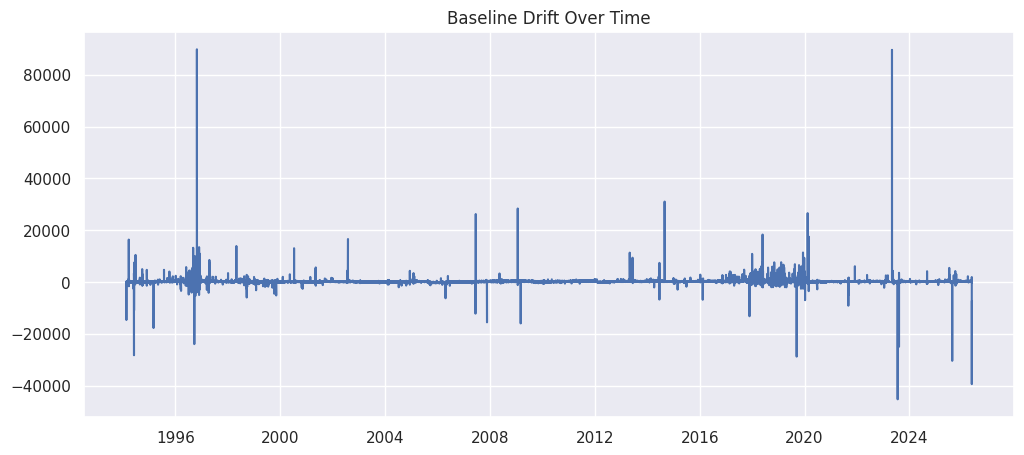

In [64]:
df_mhd_ch4_v4['baseline_drift'] = df_mhd_ch4_v4['CH4_end_level'] - df_mhd_ch4_v4['CH4_start_level']
plt.figure(figsize=(12,5))
plt.plot(df_mhd_ch4_v4['datetime'], df_mhd_ch4_v4['baseline_drift'])
plt.title('Baseline Drift Over Time')
plt.show()

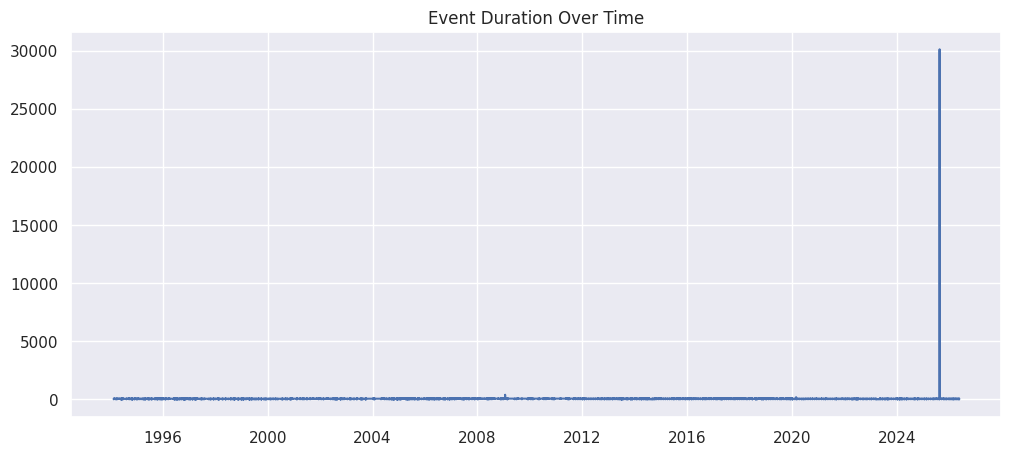

In [65]:
df_mhd_ch4_v4['duration'] = (df_mhd_ch4_v4['CH4_end_time']- df_mhd_ch4_v4['CH4_start_time'])

plt.figure(figsize=(12,5))
plt.plot(df_mhd_ch4_v4['datetime'], df_mhd_ch4_v4['duration'])
plt.title("Event Duration Over Time")
plt.show()

In [66]:
# examine duration spike
df_mhd_ch4_v4[df_mhd_ch4_v4['duration'] > 100].head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,pflow,psamp,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,label,datetime_str,datetime,baseline_drift,duration
377766,090121,112300,tank,499310,J-116,11,0.0,40.00,19.52,773.80,737.68,737.2,90.4,34.72,99999999.0,1.000000e+09,45.48,79.4,471.8,10400.0,38773.00000,454.43320,1907.06300,NaN,454.6660,1908.0400,4.18670,454.43320,1907.06300,NaN,858205.00,3601524.00,NaN,4.297,NaN,1888.518,1,1,1,090121112300,2009-01-21 11:23:00,28373.00000,392.4
377772,090121,132300,tank,509613,J-116,11,0.0,40.00,19.95,779.40,735.29,735.2,89.8,34.32,99999999.0,1.000000e+09,44.83,78.2,470.6,24944.0,39475.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.234,NaN,1888.518,0,0,0,090121132300,2009-01-21 13:23:00,14531.00000,392.4
661957,200227,101200,tank,P5-EF38PMQ,J-231,11,0.0,40.00,20.24,810.00,753.18,753.3,99.2,23.11,99999999.0,1.000000e+09,29.94,88.2,271.4,35149.0,52675.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1931.478,1,1,1,200227101200,2020-02-27 10:12:00,17526.00000,183.2
798738,250818,183700,-,J-280,0,0,40.0,20.06,NaN,764.75,NaN,94.6,7.3,72415.00,592587.0,1.140000e+00,82.80,130.2,30259.0,30405.0,0.42648,0.39938,0.39938,0.4277,0.4006,0.9308,0.42648,0.39938,0.39938,854.83,800.51,800.51,10.708,NaN,2004.399,A,0,0,0,250818183700,2025-08-18 18:37:00,-30404.57352,30128.8


CH4_ht.1 and CH4_area all 999999.0 
all tank type

duration spike -> error?

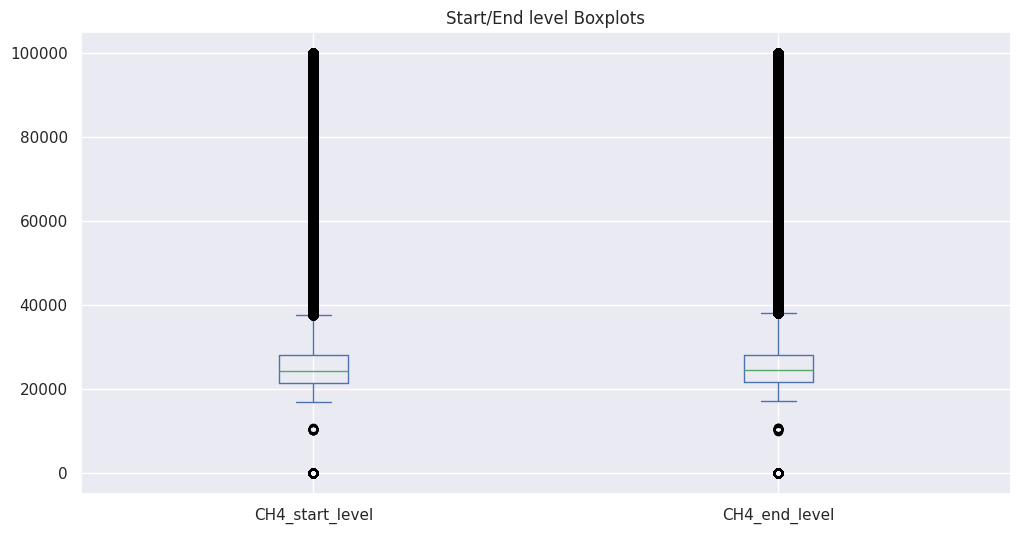

In [67]:
df_mhd_ch4_v4[['CH4_start_level','CH4_end_level']].plot(kind='box', figsize=(12,6))
plt.title("Start/End level Boxplots")
plt.show()

# explore sample and port (boxplot)

Text(0.5, 1.0, 'sample vs. ch4_c')

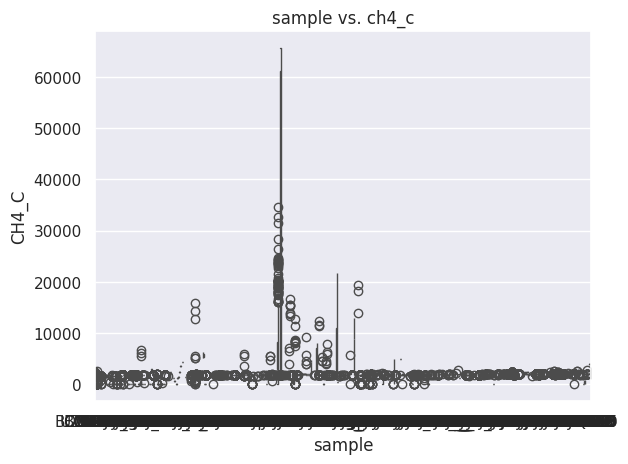

In [68]:
sns.boxplot(x='sample', y='CH4_C', data=df_mhd_ch4_v3)
plt.title('sample vs. ch4_c')

Text(0.5, 1.0, 'Port vs. rt')

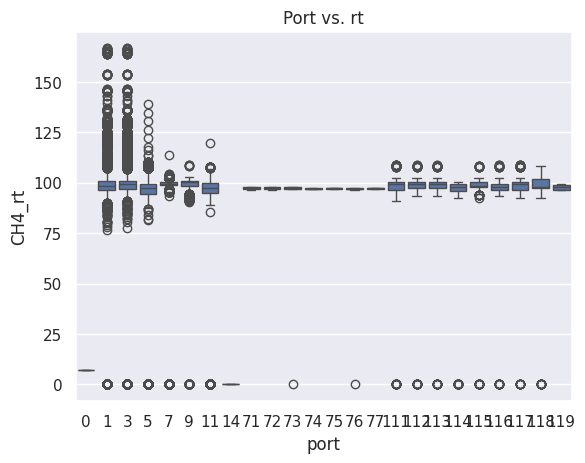

In [69]:
sns.boxplot(x='port', y='CH4_rt', data=df_mhd_ch4_v3)
plt.title('Port vs. rt')

Text(0.5, 1.0, 'Port vs. W')

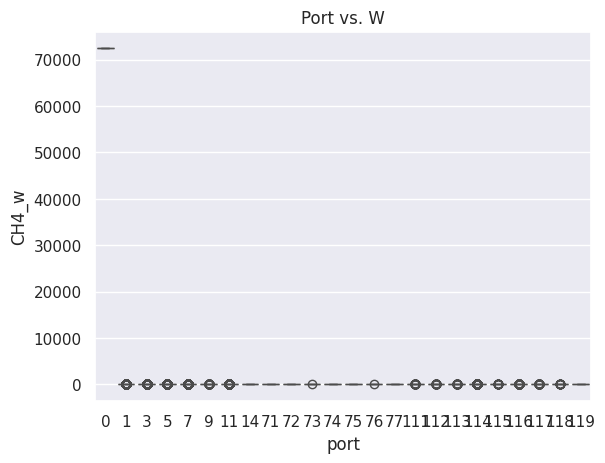

In [70]:
sns.boxplot(x='port', y='CH4_w', data=df_mhd_ch4_v3)
plt.title('Port vs. W')


===================================================

label 1 data distribution in ht and a are almost the same
that potentially means ht and area are highly related.

# Feature Engineering

Already know
CH4_ht.1 == 999999999
CH4_area == 999999999
rt == 0
w == 0
-------- error

seen flag NAN as correct data

In [71]:
df_mhd_ml_v1 = df_mhd_ch4_raw.copy()

In [72]:
df_mhd_ml_v1 ["CH4_flag"] = df_mhd_ml_v1 ["CH4_flag"].fillna(" ")
df_mhd_ml_v1 ["CH4_flag_ht"] = df_mhd_ml_v1 ["CH4_flag_ht"].fillna(" ")
df_mhd_ml_v1 ["CH4_flag_a"] = df_mhd_ml_v1 ["CH4_flag_a"].fillna(" ")

In [73]:
df_mhd_ml_v1 ["CH4_flag_raw"] = df_mhd_ml_v1 ["CH4_flag"]
df_mhd_ml_v1 ["CH4_flag_ht_raw"] = df_mhd_ml_v1 ["CH4_flag_ht"]
df_mhd_ml_v1 ["CH4_flag_a_raw"] = df_mhd_ml_v1 ["CH4_flag_a"]

In [74]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F


In [75]:
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":1, 
        }

df_mhd_ml_v1 ["CH4_flag_ht_bin"] = df_mhd_ml_v1 ["CH4_flag_ht_raw"].map(mapping)
df_mhd_ml_v1 ["CH4_flag_a_bin"] = df_mhd_ml_v1 ["CH4_flag_a_raw"].map(mapping)


In [76]:
# prevent NAN values, NAN -> 0 (good)
df_mhd_ml_v1 ["CH4_flag_ht_bin"] = df_mhd_ml_v1 ["CH4_flag_ht_bin"].fillna(0)
df_mhd_ml_v1 ["CH4_flag_a_bin"] = df_mhd_ml_v1 ["CH4_flag_a_bin"].fillna(0)

In [77]:
df_mhd_ml_v1['label1'] = (
    (df_mhd_ml_v1['CH4_flag_ht_bin'] == 1) |
    (df_mhd_ml_v1['CH4_flag_a_bin'] == 1)
).astype(int)

In [78]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1


datetime create

In [79]:
df_mhd_ml_v1['date'] = df_mhd_ml_v1['date'].astype(str).str.zfill(6)
df_mhd_ml_v1['time'] = df_mhd_ml_v1['time'].astype(str).str.zfill(6)

df_mhd_ml_v1['datetime_str'] = df_mhd_ml_v1['date'] + df_mhd_ml_v1['time']

df_mhd_ml_v1['datetime'] = pd.to_datetime(df_mhd_ml_v1['datetime_str'], format='%y%m%d%H%M%S')

df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216182000,1994-02-16 18:20:00
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216184000,1994-02-16 18:40:00
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216190000,1994-02-16 19:00:00
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216192000,1994-02-16 19:20:00
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216194000,1994-02-16 19:40:00


In [80]:
df_mhd_ml_v1['is_ht_999'] = (df_mhd_ml_v1['CH4_ht'] == 9999999.0)
df_mhd_ml_v1['is_area_999'] = (df_mhd_ml_v1['CH4_area'] == 9999999.0) 

In [81]:
df_mhd_ml_v1[df_mhd_ml_v1['is_area_999'] == True]

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999


In [82]:
(df_mhd_ml_v1['is_area_999'] == True).sum()

np.int64(0)

In [83]:
df_mhd_ml_v1['is_rt_zero'] = (df_mhd_ml_v1['CH4_rt'] == 0)
df_mhd_ml_v1['is_w_zero'] = (df_mhd_ml_v1['CH4_w'] == 0)

In [84]:
print((df_mhd_ml_v1['is_rt_zero'] == True).sum())
print((df_mhd_ml_v1['is_w_zero'] == True).sum())

16699
16706


In [85]:
df_mhd_ml_v1['duration'] = (df_mhd_ml_v1['CH4_end_time'] - df_mhd_ml_v1['CH4_start_time'])
df_mhd_ml_v1['is_duration_spike'] = (df_mhd_ml_v1['duration']>100)


In [86]:
df_mhd_ml_v1['baseline_drift'] = df_mhd_ml_v1['CH4_end_level'] - df_mhd_ml_v1['CH4_start_level']


In [87]:
# df_mh_ml_v1['CalNorm_ratio'] not sure

In [88]:
df_mhd_ml_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 57 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   date               817955 non-null  object        
 1   time               817955 non-null  object        
 2   type               817955 non-null  object        
 3   sample             817955 non-null  object        
 4   standard           817955 non-null  object        
 5   port               817955 non-null  int64         
 6   ht                 817955 non-null  float64       
 7   tmod               705671 non-null  float64       
 8   tamb               705670 non-null  float64       
 9   lab_temp           1 non-null       float64       
 10  pflow              815553 non-null  float64       
 11  psamp              815625 non-null  float64       
 12  ploop              1 non-null       float64       
 13  pamb               815551 non-null  float64 

**Create label2**

In [89]:
df_mhd_ml_v1['label2'] = (
    (df_mhd_ml_v1['label1'] == 1) |
    (df_mhd_ml_v1['is_ht_999'] == True)|
    (df_mhd_ml_v1['is_area_999'] == True)|
    (df_mhd_ml_v1['is_rt_zero'] == True)|
    (df_mhd_ml_v1['is_w_zero'] == True)|
    (df_mhd_ml_v1['is_duration_spike'] == True)
).astype(int)

In [90]:
df_mhd_ml_v1['ht_area_ratio'] = df_mhd_ml_v1['CH4_ht'] /df_mhd_ml_v1['CH4_area']

In [91]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,1,NaN
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,1,NaN
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,1,NaN
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,1,NaN
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,1,NaN


In [92]:
df_mhd_ml_v1['type'].value_counts()

type
std        414114
air        372609
tank        15952
cal560       2616
cal660       2609
cal860       2607
cal960       2603
cal1060      2595
cal           987
labair        653
blank         521
cal150         12
tank100         6
cal30           6
cal225          6
cal300          6
cal120          6
cal60           6
cal180          6
cal90           6
cal45           4
cal15           3
cal165          3
cal135          3
cal75           3
cal105          3
cal250          3
cal200          3
cal500          3
-               1
Name: count, dtype: int64

In [93]:
def normalize_type(t):
    t = str(t).lower().strip()

    if t=='std':
        return 'std'
    if t in ['air', 'labair']:
        return 'air'
    if t.startswith('tank'):
        return 'tank'
    if t == 'blank':
        return 'blank'
    if t.startswith('cal'):
        return 'cal'

    return 'other'

df_mhd_ml_v1['type_norm'] = df_mhd_ml_v1['type'].apply(normalize_type)

In [94]:
(df_mhd_ml_v1['type_norm'] == 'blank').sum()

np.int64(521)

In [95]:
df_mhd_ml_v1.head(10)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,type_norm
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,air
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,air
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,air
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,air
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,air
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,1,NaN,air
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,1,NaN,air
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,1,NaN,air
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,1,NaN,air
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,1,NaN,air


In [96]:
df_mhd_ml_v1 = df_mhd_ml_v1.sort_values('datetime') # sorting old to latest

# find out std time
df_mhd_ml_v1['last_std_time'] = df_mhd_ml_v1.loc[df_mhd_ml_v1['type_norm'] == 'std', 'datetime'].shift(1)

#fill previous time
df_mhd_ml_v1['last_std_time'] = df_mhd_ml_v1['last_std_time'].ffill()

df_mhd_ml_v1['seconds_since_last_std'] = (df_mhd_ml_v1['datetime'] - df_mhd_ml_v1['last_std_time']).dt.total_seconds()
# to understand how many seconds have passed since the last reference point (std)

In [97]:
df_mhd_ml_v1.head(10)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,type_norm,last_std_time,seconds_since_last_std
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,air,NaT,NaN
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,air,NaT,NaN
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,1,NaN,air,NaT,NaN


In [98]:
all_cat = ['std', 'air', 'tank', 'blank', 'cal', 'other']
df_mhd_ml_v1['type_norm'] = pd.Categorical(df_mhd_ml_v1['type_norm'], categories=all_cat)


In [99]:
df_mhd_ml_v1 = pd.get_dummies(df_mhd_ml_v1, columns=['type_norm'], prefix='type', dtype=int)

In [100]:
df_mhd_ml_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaT,NaN,0,1,0,0,0,0
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaT,NaN,0,1,0,0,0,0
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
5,940216,182000,air,10m,G-024,3,10.0,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
6,940216,184000,air,10m,G-024,3,10.0,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
7,940216,190000,air,10m,G-024,3,10.0,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
8,940216,192000,air,10m,G-024,3,10.0,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0
9,940216,194000,air,10m,G-024,3,10.0,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0


improvement:
ML-B: require some other feature

In [101]:
df_mhd_ml_v1 = df_mhd_ml_v1.sort_values("datetime")

df_mhd_ml_v1['last_cal_time'] = df_mhd_ml_v1.loc[df_mhd_ml_v1['type_cal'] == 1, 'datetime'].shift(1)

df_mhd_ml_v1['last_cal_time'] = df_mhd_ml_v1['last_cal_time'].ffill()

df_mhd_ml_v1['seconds_since_last_cal'] = (
    df_mhd_ml_v1['datetime'] - df_mhd_ml_v1['last_cal_time']
).dt.total_seconds()
#to understand how many seconds have passed since the last cal

In [102]:
df_mhd_ml_v1.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10.0,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0,NaT,NaN
1,940216,144900,air,10m,G-024,3,10.0,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0,NaT,NaN
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaT,NaN,0,1,0,0,0,0,NaT,NaN
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaT,NaN,0,1,0,0,0,0,NaT,NaN
4,940216,180000,air,10m,G-024,3,10.0,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaT,NaN,0,1,0,0,0,0,NaT,NaN


In [103]:
df_mhd_ml_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 69 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date                    817955 non-null  object        
 1   time                    817955 non-null  object        
 2   type                    817955 non-null  object        
 3   sample                  817955 non-null  object        
 4   standard                817955 non-null  object        
 5   port                    817955 non-null  int64         
 6   ht                      817955 non-null  float64       
 7   tmod                    705671 non-null  float64       
 8   tamb                    705670 non-null  float64       
 9   lab_temp                1 non-null       float64       
 10  pflow                   815553 non-null  float64       
 11  psamp                   815625 non-null  float64       
 12  ploop                   1 non-

In [104]:
df_mhd_ml_v1.to_csv("../data/processed/mhd_ch4_ml.csv", index=False)

# Datasets

In [105]:
# Datasets A peak only
dataset_A_cols = [
    'CH4_rt', 'CH4_w', "CH4_ht","CH4_area", "CH4_skew",
    'is_ht_999', 'is_area_999',	'is_rt_zero', 'is_w_zero',
    'ht_area_ratio',
    'label1'
]

dataset_B_cols = [
    #peak
    'CH4_rt', 'CH4_w', "CH4_ht","CH4_area", "CH4_skew",
    'is_ht_999', 'is_area_999',	'is_rt_zero', 'is_w_zero',
    'ht_area_ratio',
    #label
    'label1',
    #cal/norm
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C', 'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd',
    #type(one-hot)
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    # simplified timestamp feature
    'seconds_since_last_std'
]

dataset_B_cols_v2 = [
    #peak
    'CH4_rt', 'CH4_w', "CH4_ht","CH4_area", "CH4_skew",
    'is_ht_999', 'is_area_999',	'is_rt_zero', 'is_w_zero',
    'ht_area_ratio',
    #label
    'label1',
    #cal/norm
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C', 'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd',
    #type(one-hot)
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    # simplified timestamp feature
    'seconds_since_last_std',
    'seconds_since_last_cal'
]

In [106]:
df_mhd_A = df_mhd_ml_v1[dataset_A_cols].copy()

In [107]:
df_mhd_A.head(20)

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
5,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
6,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
7,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
8,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1
9,0.0,0.00,0.0,0.0,0.00,False,False,True,True,NaN,1


In [108]:
df_mhd_A_v2 = df_mhd_A.copy()

In [109]:
# convert ht_area_ration  NAN-> -999, 'cause randomforest cann't put NAN
df_mhd_A_v2['ht_area_ratio'] = df_mhd_A_v2['ht_area_ratio'].fillna(-999)

In [110]:
df_mhd_A_v2.head(20)

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
5,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
6,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
7,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
8,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1
9,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1


Dataset explain:
label1: CH4_flag_ht or CH4_flag_a is not space -> 1 (error); space, 0(correct)

**Dataset B**

In [111]:
df_mhd_B = df_mhd_ml_v1[dataset_B_cols].copy()
df_mhd_B_v2 = df_mhd_B.copy()
df_mhd_B_v2['ht_area_ratio'] = df_mhd_B_v2['ht_area_ratio'].fillna(-999)

In [112]:
df_mhd_B_v2.head(20)

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,type_air,type_blank,type_cal,type_other,type_std,type_tank,seconds_since_last_std
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
5,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
6,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
7,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
8,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN
9,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,1,0,0,0,0,0,NaN


In [113]:
df_mhd_B_v2 = df_mhd_ml_v1[dataset_B_cols].copy()
df_mhd_B_v2_v2 = df_mhd_B.copy()
df_mhd_B_v2_v2['ht_area_ratio'] = df_mhd_B_v2_v2['ht_area_ratio'].fillna(-999)

In [114]:
calib_cols =[
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 
    'CH4_norm_ht','CH4_norm_a', 'CH4_norm_w', 
    'CH4_R_ht', 'CH4_R_a', 'CH4_R', 
    'CH4_C_ht', 'CH4_C_a', 'CH4_C', 
    'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd'
]
for col in calib_cols:
    df_mhd_B_v2_v2[col + "_isnan"] = df_mhd_B_v2_v2[col].isna().astype(int)
    df_mhd_B_v2_v2[col] = df_mhd_B_v2_v2[col].fillna(0)


In [115]:
df_mhd_B_v2_v2.head()

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,is_ht_999,is_area_999,is_rt_zero,is_w_zero,ht_area_ratio,label1,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,type_air,type_blank,type_cal,type_other,type_std,type_tank,seconds_since_last_std,CH4_Rl_ht_isnan,CH4_Rl_a_isnan,CH4_Rl_isnan,CH4_norm_ht_isnan,CH4_norm_a_isnan,CH4_norm_w_isnan,CH4_R_ht_isnan,CH4_R_a_isnan,CH4_R_isnan,CH4_C_ht_isnan,CH4_C_a_isnan,CH4_C_isnan,CH4_std_stdev_isnan,CH4_std_rep_isnan,CH4_Cstd_isnan
0,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1692.489,1,0,0,0,0,0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
1,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1692.489,1,0,0,0,0,0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
2,109.8,2.60,190908.0,496440.0,0.63,False,False,False,False,0.384554,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1692.489,1,0,0,0,0,0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
3,94.8,6.85,151667.0,1065982.0,1.02,False,False,False,False,0.142279,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1692.489,1,0,0,0,0,0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
4,0.0,0.00,0.0,0.0,0.00,False,False,True,True,-999.000000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1692.489,1,0,0,0,0,0,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0


# ML 

**Note: model.py function including:**

plot_importance(model, feature_names, title_suffix=""):

random_forest_model(X_train, y_train, X_test, y_test, feature_names, 
                        experiment_run_name='RF_Model',n_estimators=200, max_depth=12, n_jobs=-1):
    """

**Dataset A: peak only**

/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Model training...


2026/06/19 16:59:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    155393
           1       0.91      0.57      0.70      8198

    accuracy                           0.98    163591
   macro avg       0.94      0.79      0.85    163591
weighted avg       0.97      0.98      0.97    163591



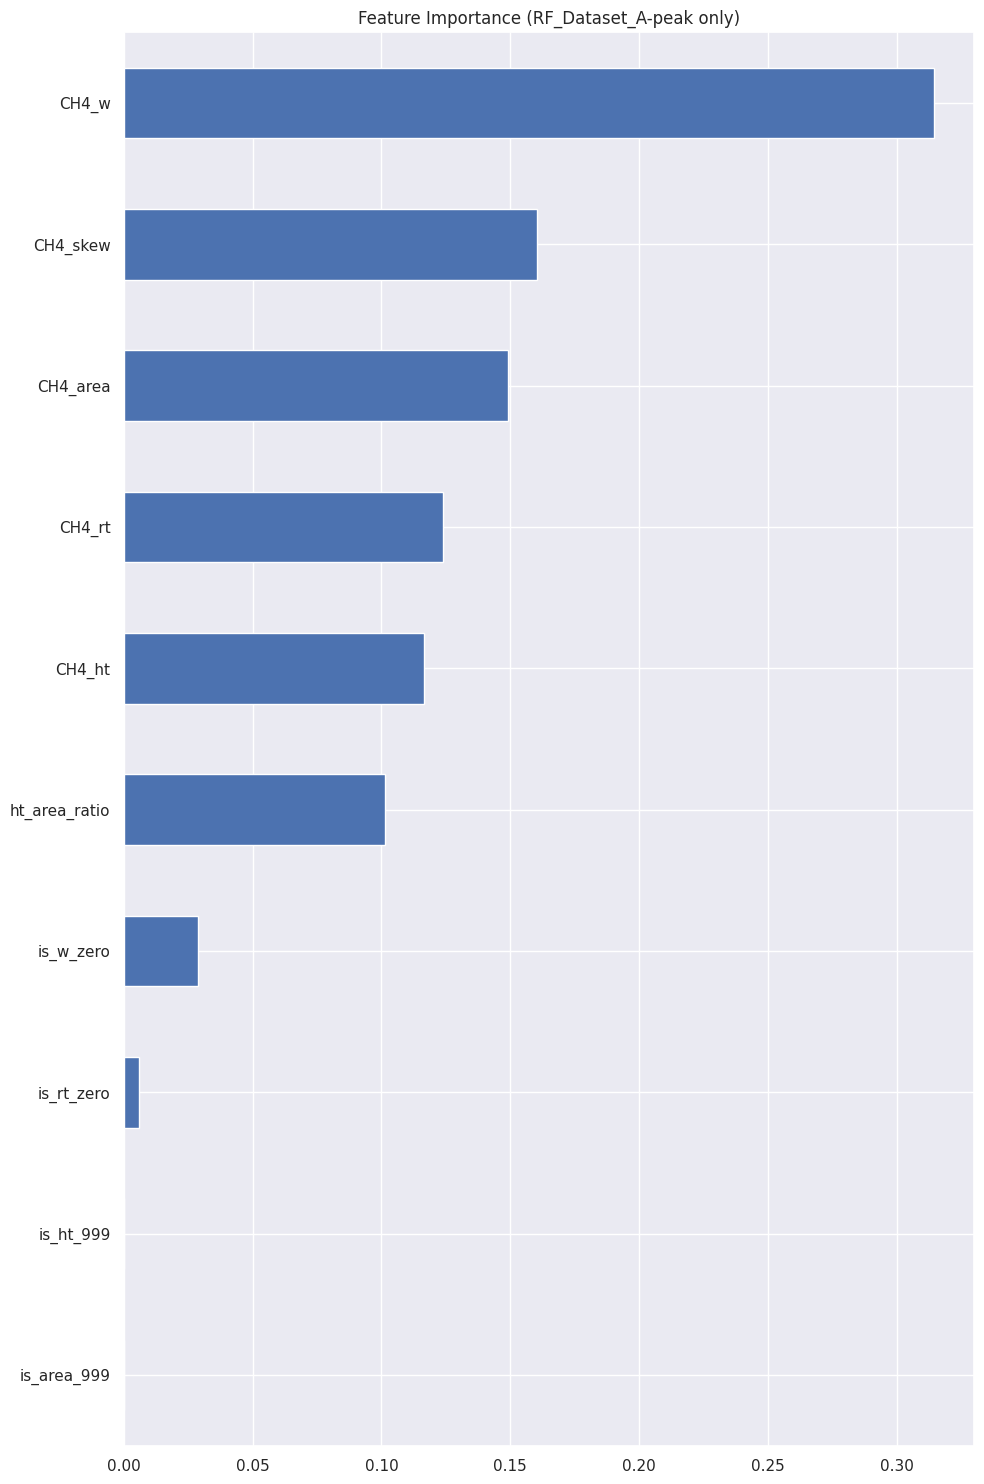

In [116]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = df_mhd_A_v2.drop(columns=['label1'])
y = df_mhd_A_v2['label1']
feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset A-peak only")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset_A-peak only',n_estimators=200, max_depth=12, n_jobs=-1
)



df_mhd_A_v2.groupby(df_mhd_A_v2['label1'])["CH4_R"].apply(lambda x: x.isna().mean())

99999 very less -> model not rely on them

**Dataset B ML - RF**

In [117]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = df_mhd_B_v2.drop(columns=['label1'])
y = df_mhd_B_v2['label1']
feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset B_ Peak, time+cal/norm")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset B_ Peak, time+cal/norm',n_estimators=200, max_depth=12, n_jobs=-1
)

Model training...


ValueError: could not convert string to float: 'A'

random split -> possibly data reveal (model learn something from time series?)

**Dataset B_v2 ML - RF**
B_v2 加上 feature    'seconds_since_last_cal', _isnan

Model training...


2026/06/08 18:24:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/08 18:24:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    155393
           1       0.99      0.84      0.91      8198

    accuracy                           0.99    163591
   macro avg       0.99      0.92      0.95    163591
weighted avg       0.99      0.99      0.99    163591



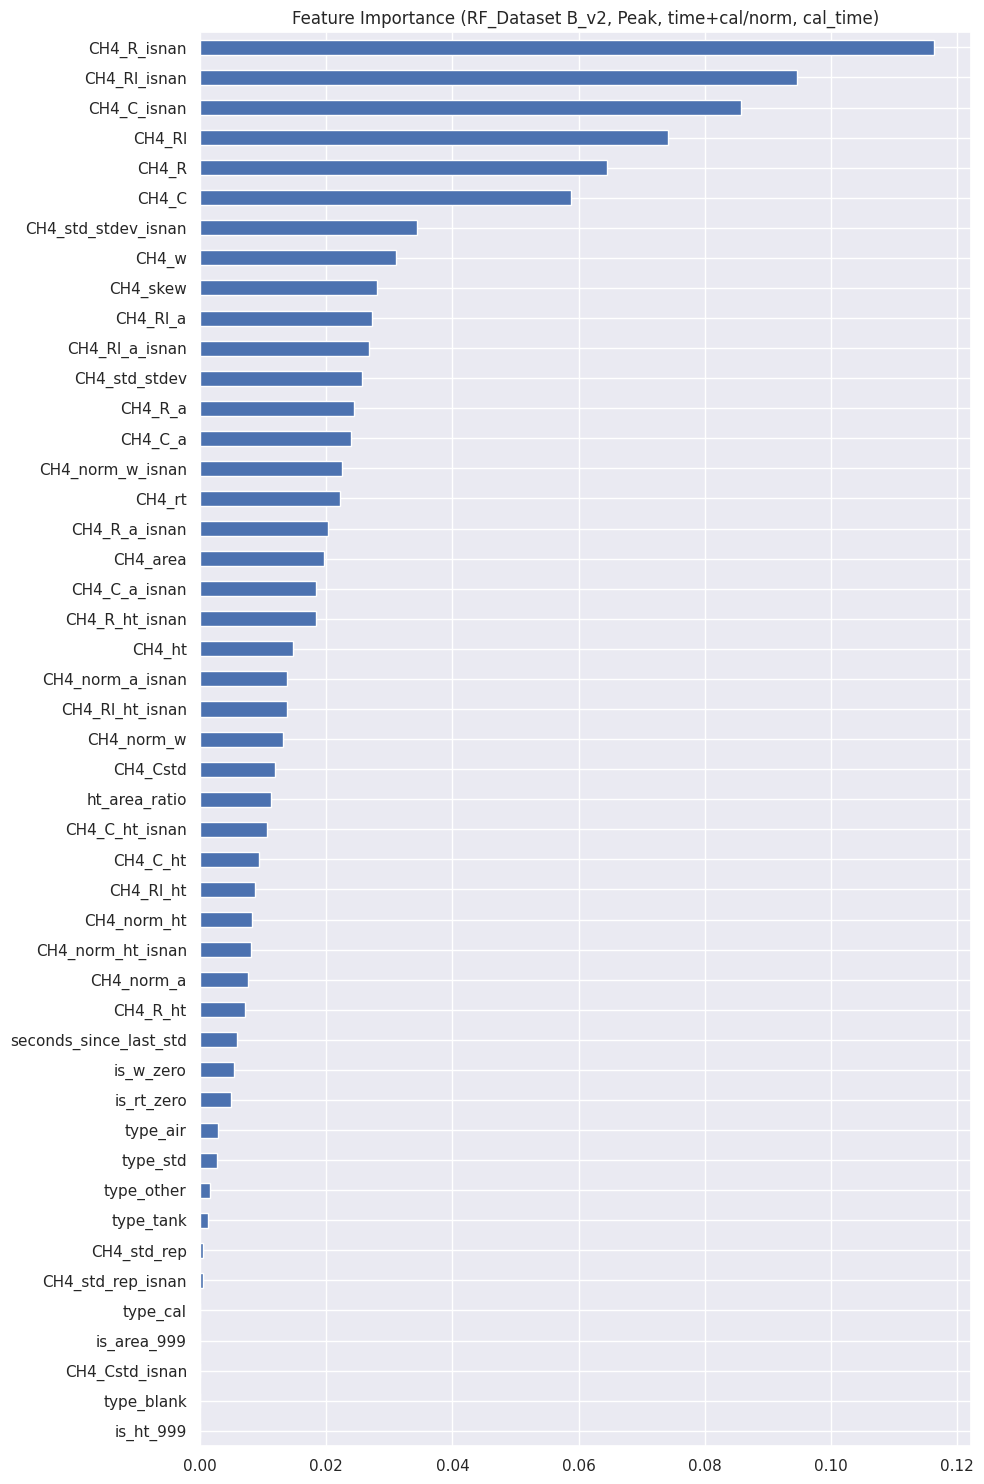

In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = df_mhd_B_v2_v2.drop(columns=['label1'])
y = df_mhd_B_v2_v2['label1']
feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset B_v2, Peak, time+cal/norm, cal_time")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset B_v2, Peak, time+cal/norm, cal_time',n_estimators=200, max_depth=12, n_jobs=-1
)

Datasets B-v2_v2
try split but time 前面80%, 後面20%
(怕前面隨機分，所以有洩漏，這次嘗試用時間分)

Model training...


2026/06/08 18:25:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/08 18:26:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    155393
           1       0.99      0.84      0.91      8198

    accuracy                           0.99    163591
   macro avg       0.99      0.92      0.95    163591
weighted avg       0.99      0.99      0.99    163591



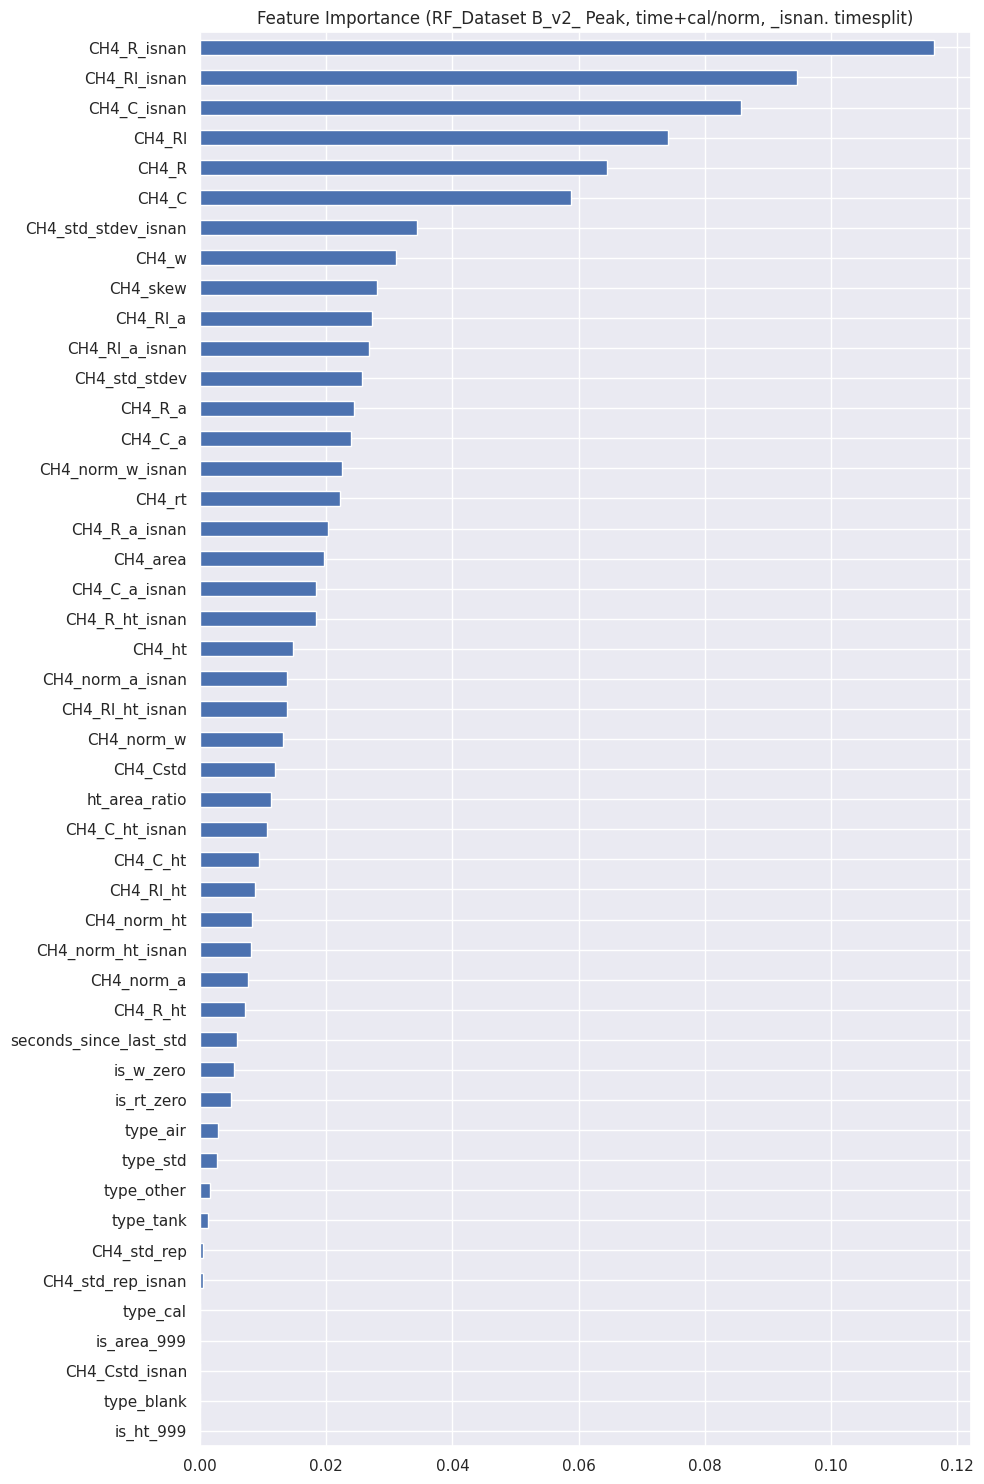

In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model
df_mhd_B_v2_v2 = df_mhd_B_v2_v2.sort_index()

X = df_mhd_B_v2_v2.drop(columns=['label1'])
y = df_mhd_B_v2_v2['label1']

split_idx = int(len(df_mhd_B_v2_v2)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset B_ Peak, time+cal/norm, _isnan. timesplit")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset B_v2_ Peak, time+cal/norm, _isnan. timesplit',n_estimators=200, max_depth=12, n_jobs=-1
)

Highly rely on RI, R, C . cal and norm feature
---------
too sensitive -> slightly fluctuation -> wrong
the model hasn't learnt how to understand the normal calibration fluctuation

# ML-improved

df_mhd_B_v3: 
1. obvious_error = (
    (df_mhd_B_v3['rt'] == 0)|
    (df_mhd_B_v3['w'] == 0)|
    (df_mhd_B_v3['CH4_ht.1'] > 900000.0)| # 999999.0 error 
    (df_mhd_B_v3['CH4_area']> 9000000.0)# 9999999.0 error
)
2. cal/norm nan values are filled by ffill() and bfill()
3. 'seconds_since_last_std'.fillna(99999999)

In [118]:
df_mhd_B_v3 = df_mhd_ml_v1.copy()

In [119]:
obvious_error = (
    (df_mhd_B_v3['CH4_rt'] == 0)|
    (df_mhd_B_v3['CH4_w'] == 0)|
    (df_mhd_B_v3['CH4_ht'] > 900000.0)| # 999999.0 error 
    (df_mhd_B_v3['CH4_area']> 9000000.0)# 9999999.0 error
)

In [120]:
df_mhd_B_v3_remaining = df_mhd_B_v3 [~obvious_error].copy()
df_mhd_B_v3_remaining.head(5)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaT,NaN,0,1,0,0,0,0,NaT,NaN
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaT,NaN,0,1,0,0,0,0,NaT,NaN
51,940217,102500,air,10m,G-024,3,10.0,40.00,29.57,NaN,834.0,753.28,NaN,753.2,98.8,8.30,190538.0,1794447.0,1.04,85.4,138.4,80100.0,80099.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.322,NaN,1692.489,,,,,,,,0,0,0,940217102500,1994-02-17 10:25:00,False,False,False,False,53.0,False,-1.0,0,0.106182,NaT,NaN,0,1,0,0,0,0,NaT,NaN
52,940217,104500,air,10m,G-024,3,10.0,40.00,27.21,NaN,832.6,753.11,NaN,753.1,95.4,7.21,176389.0,1427808.0,1.08,83.4,132.8,60959.0,60043.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.331,NaN,1692.489,,,,,,,,0,0,0,940217104500,1994-02-17 10:45:00,False,False,False,False,49.4,False,-916.0,0,0.123538,NaT,NaN,0,1,0,0,0,0,NaT,NaN
53,940217,110500,air,10m,G-024,3,10.0,39.99,26.79,NaN,832.6,753.00,NaN,752.9,94.6,8.66,168522.0,1566793.0,1.44,82.8,135.0,82021.0,67370.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.331,NaN,1692.489,,,,,,,,0,0,0,940217110500,1994-02-17 11:05:00,False,False,False,False,52.2,False,-14651.0,0,0.107559,NaT,NaN,0,1,0,0,0,0,NaT,NaN


In [121]:
df_mhd_B_v3_remaining = df_mhd_B_v3_remaining.sort_values('datetime') # make sure fill with past values rather than future values
cal_norm_cols = [
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 
    'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 
    'CH4_C_a', 'CH4_C', 'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd'
]

df_mhd_B_v3_remaining[cal_norm_cols] = df_mhd_B_v3_remaining[cal_norm_cols].ffill()

# prevent first data is NAN
df_mhd_B_v3_remaining[cal_norm_cols] = df_mhd_B_v3_remaining[cal_norm_cols].bfill()

In [122]:
dataset_B_cols_v3 =[# peak
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew','ht_area_ratio',

 'label1',

 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',

 'type_air',
 'type_blank',
 'type_cal',
 'type_other',
 'type_std',
 'type_tank',

 'seconds_since_last_std',
 'date',
 'time']

In [123]:
df_mhd_B_v3_remaining = df_mhd_B_v3_remaining[dataset_B_cols_v3]

In [124]:
df_mhd_B_v3_remaining['seconds_since_last_std'] = df_mhd_B_v3_remaining['seconds_since_last_std'].fillna(99999999)

In [125]:
df_mhd_B_v3_remaining.head(5)

,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,ht_area_ratio,label1,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,type_air,type_blank,type_cal,type_other,type_std,type_tank,seconds_since_last_std,date,time
2,109.8,2.60,190908.0,496440.0,0.63,0.384554,1,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.322,3.005,1692.489,1,0,0,0,0,0,99999999.0,940216,150900
3,94.8,6.85,151667.0,1065982.0,1.02,0.142279,0,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.322,3.005,1692.489,1,0,0,0,0,0,99999999.0,940216,152900
51,98.8,8.30,190538.0,1794447.0,1.04,0.106182,0,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.322,3.005,1692.489,1,0,0,0,0,0,99999999.0,940217,102500
52,95.4,7.21,176389.0,1427808.0,1.08,0.123538,0,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.331,3.005,1692.489,1,0,0,0,0,0,99999999.0,940217,104500
53,94.6,8.66,168522.0,1566793.0,1.44,0.107559,0,1.08466,1.08577,1.08466,1.0846,1.0857,1.0008,1.08466,1.08577,1.08466,1835.78,1837.65,1835.78,2.331,3.005,1692.489,1,0,0,0,0,0,99999999.0,940217,110500


Model training...


2026/06/08 18:27:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/08 18:28:08 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    154993
           1       0.99      0.57      0.72      5246

    accuracy                           0.99    160239
   macro avg       0.99      0.78      0.86    160239
weighted avg       0.99      0.99      0.98    160239



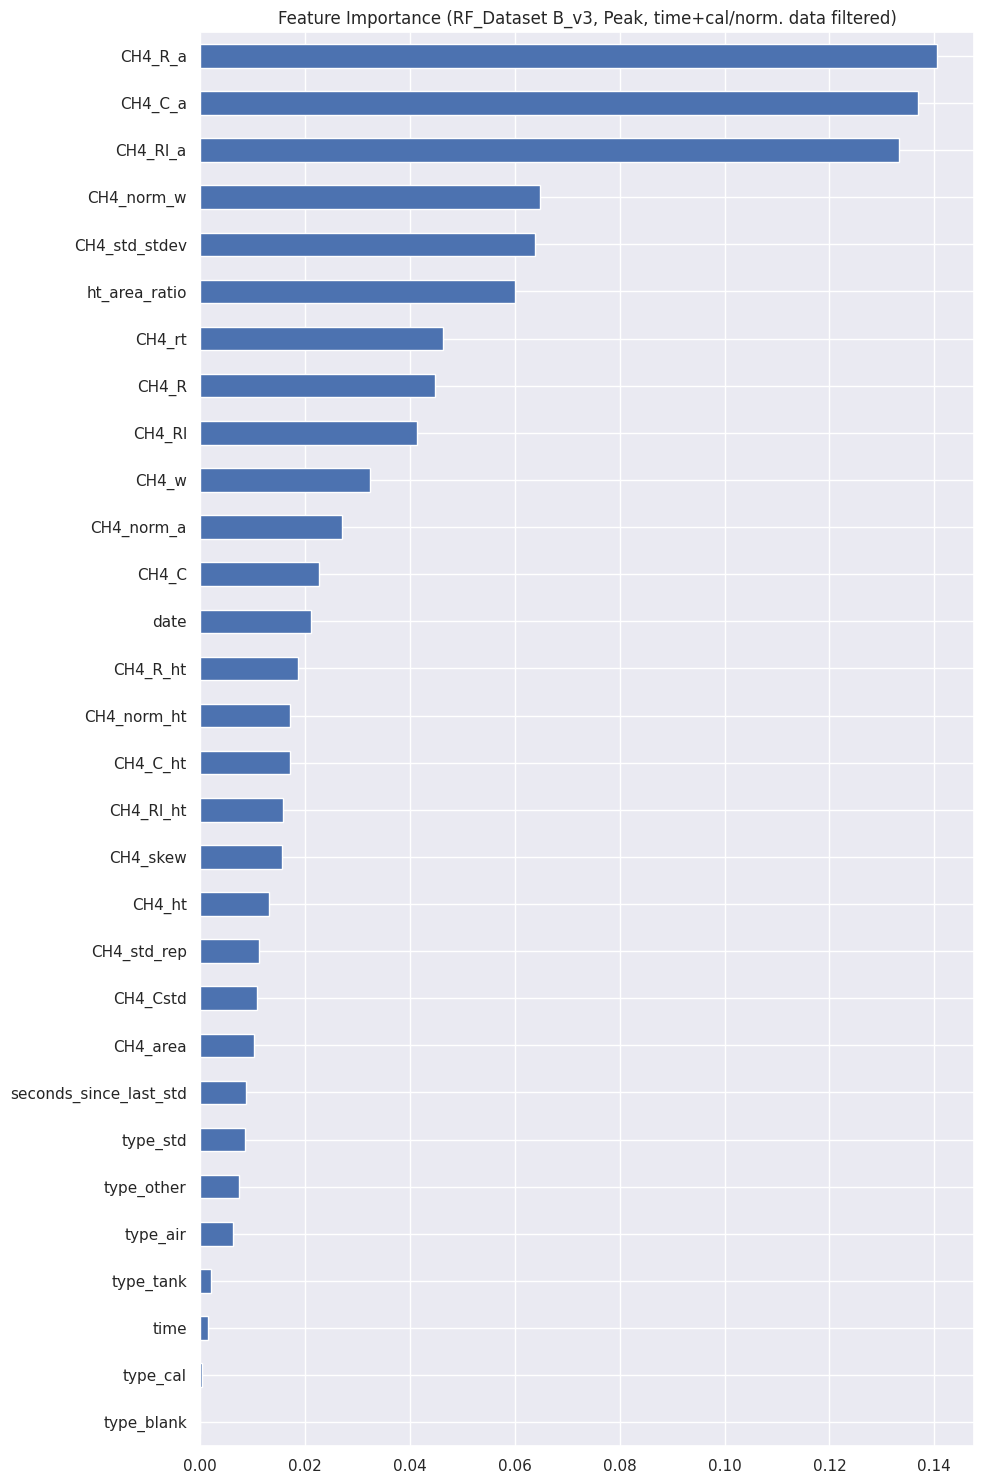

In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = df_mhd_B_v3_remaining.drop(columns=['label1'])
y = df_mhd_B_v3_remaining['label1']
feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset B_v3, Peak, time+cal/norm. data filtered")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset B_v3, Peak, time+cal/norm. data filtered',n_estimators=200, max_depth=12, n_jobs=-1
)

*results:* 
 
  
  
Data leakage?
bfill() shouldnot use.

**df_mhd_B_v4**: copy of df_mhd_B_v3 but without 'CH4_Rl_a', #'CH4_R_a' #'CH4_C_a'

In [126]:
df_mhd_B_v4 = df_mhd_ml_v1.copy()
obvious_error = (
    (df_mhd_B_v4['CH4_rt'] == 0)|
    (df_mhd_B_v4['CH4_w'] == 0)|
    (df_mhd_B_v4['CH4_ht'] > 900000.0)| # 999999.0 error 
    (df_mhd_B_v4['CH4_area']> 9000000.0)# 9999999.0 error
)
df_mhd_B_v4_remaining = df_mhd_B_v4 [~obvious_error].copy()


df_mhd_B_v4_remaining = df_mhd_B_v4_remaining.sort_values('datetime') # make sure fill with past values rather than future values
cal_norm_cols = [
    'CH4_Rl_ht','CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 
    'CH4_norm_w', 'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 
    'CH4_C_a', 'CH4_C', 'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd'
]

df_mhd_B_v4_remaining[cal_norm_cols] = df_mhd_B_v4_remaining[cal_norm_cols].ffill()


In [127]:
dataset_B_cols_v4 =[# peak
'CH4_rt','CH4_w','CH4_ht','CH4_area','CH4_skew','ht_area_ratio',
'label1', 'CH4_Rl_ht',
#'CH4_Rl_a',
'CH4_Rl','CH4_norm_ht', 'CH4_norm_a','CH4_norm_w','CH4_R_ht',
#'CH4_R_a',
'CH4_R',
#'CH4_C_a',
'CH4_C','CH4_std_stdev','CH4_std_rep','CH4_Cstd', 'type_air','type_blank','type_cal','type_other',
'type_std','type_tank','seconds_since_last_std','date','time'
]

In [128]:
df_mhd_B_v4_remaining.head(5)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
2,940216,150900,air,10m,G-024,3,10.0,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaT,NaN,0,1,0,0,0,0,NaT,NaN
3,940216,152900,air,10m,G-024,3,10.0,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaT,NaN,0,1,0,0,0,0,NaT,NaN
51,940217,102500,air,10m,G-024,3,10.0,40.00,29.57,NaN,834.0,753.28,NaN,753.2,98.8,8.30,190538.0,1794447.0,1.04,85.4,138.4,80100.0,80099.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.322,NaN,1692.489,,,,,,,,0,0,0,940217102500,1994-02-17 10:25:00,False,False,False,False,53.0,False,-1.0,0,0.106182,NaT,NaN,0,1,0,0,0,0,NaT,NaN
52,940217,104500,air,10m,G-024,3,10.0,40.00,27.21,NaN,832.6,753.11,NaN,753.1,95.4,7.21,176389.0,1427808.0,1.08,83.4,132.8,60959.0,60043.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.331,NaN,1692.489,,,,,,,,0,0,0,940217104500,1994-02-17 10:45:00,False,False,False,False,49.4,False,-916.0,0,0.123538,NaT,NaN,0,1,0,0,0,0,NaT,NaN
53,940217,110500,air,10m,G-024,3,10.0,39.99,26.79,NaN,832.6,753.00,NaN,752.9,94.6,8.66,168522.0,1566793.0,1.44,82.8,135.0,82021.0,67370.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.331,NaN,1692.489,,,,,,,,0,0,0,940217110500,1994-02-17 11:05:00,False,False,False,False,52.2,False,-14651.0,0,0.107559,NaT,NaN,0,1,0,0,0,0,NaT,NaN


In [129]:
df_mhd_B_v4_remaining = df_mhd_B_v4_remaining[dataset_B_cols_v4]

In [130]:
df_mhd_B_v4_remaining['seconds_since_last_std'] = df_mhd_B_v4_remaining['seconds_since_last_std'].fillna(99999999)

Model training...


2026/06/08 18:28:52 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/08 18:29:57 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    154993
           1       0.98      0.61      0.75      5246

    accuracy                           0.99    160239
   macro avg       0.98      0.80      0.87    160239
weighted avg       0.99      0.99      0.99    160239



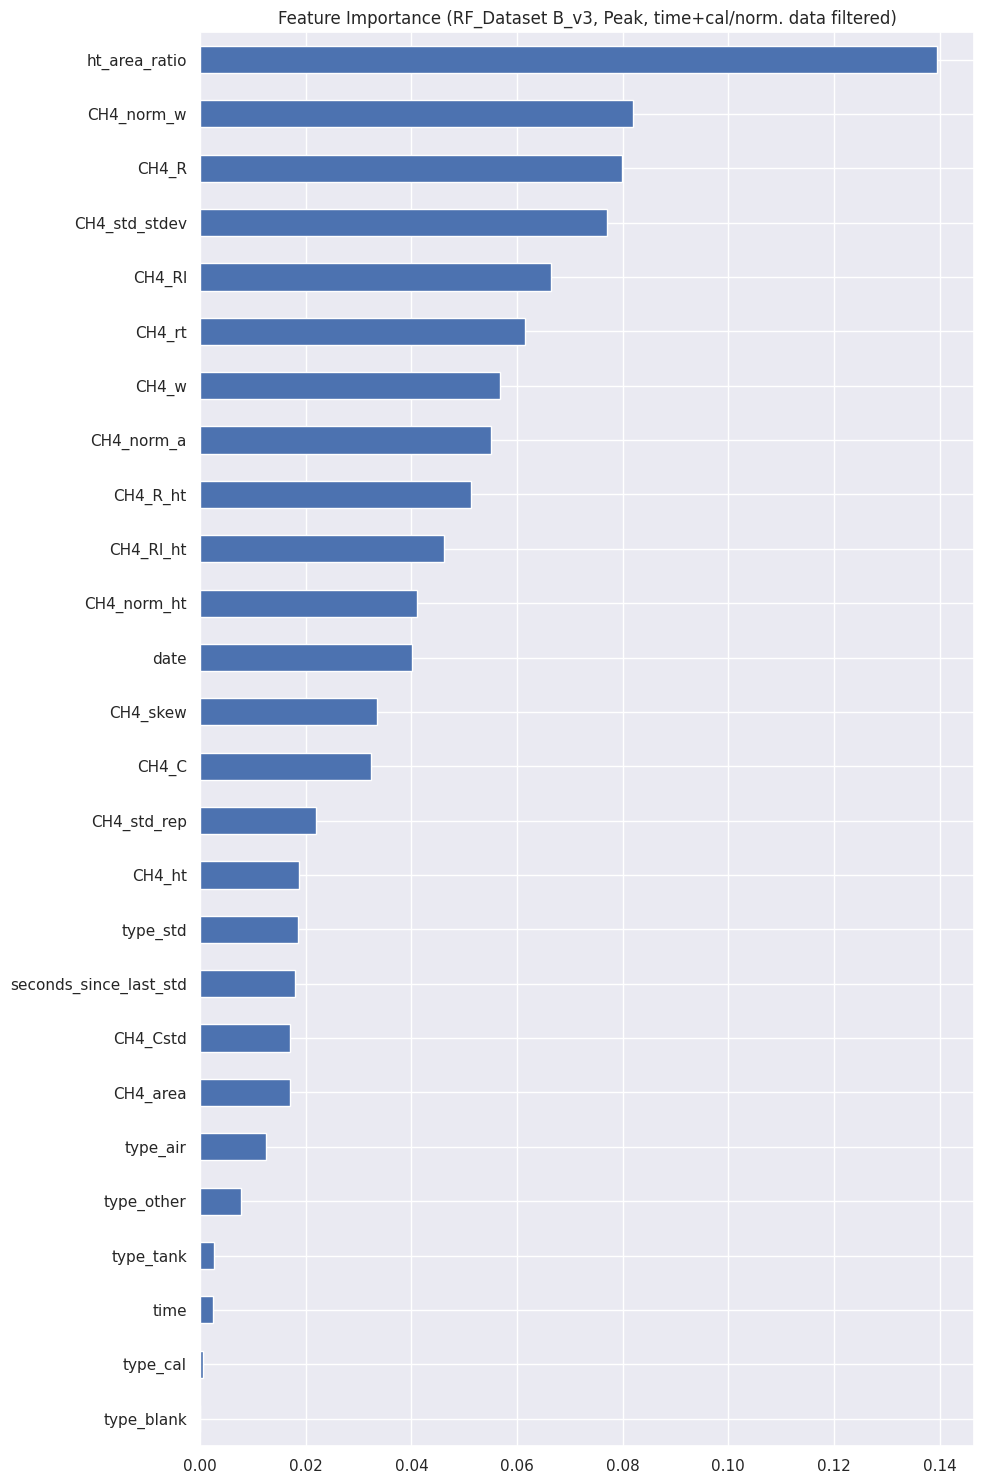

In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

X = df_mhd_B_v4_remaining.drop(columns=['label1'])
y = df_mhd_B_v4_remaining['label1']

feature_cols = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mlflow.set_experiment("Dataset B_v3, Peak, time+cal/norm. data filtered")
print("Model training...")
model = random_forest_model(
    X_train, y_train, X_test, y_test,
    feature_names=feature_cols,
    experiment_run_name='RF_Dataset B_v3, Peak, time+cal/norm. data filtered',n_estimators=200, max_depth=12, n_jobs=-1
)

*results:*
No bfill()-> the same
without  #'CH4_Rl_a', #'CH4_R_a' #'CH4_C_a'
-> the same

tomorrow try-> no fill() keep nan

=============== Summary

only data_a model can be used.
==================

**把你的代碼變成 py檔案!!!**
**或是函數!!**
**還有那些圖表**